In [1]:
import os, sys, time, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import joblib

# Global configuration
SEED = 42
np.random.seed(SEED)
REG_NO = "21BCE1001"

print(f"Python Platform: {platform.platform()}")
print(f"Pandas Version:  {pd.__version__}")
print(f"NumPy Version:   {np.__version__}")
print(f"Seeded Random State: {SEED}")

Python Platform: Windows-10-10.0.26100-SP0
Pandas Version:  2.2.2
NumPy Version:   1.26.4
Seeded Random State: 42


In [2]:
# Load frozen UCI Online Retail dataset
PATH = 'online_retail.csv'
df_raw = pd.read_csv(PATH)
raw_count = len(df_raw)
missing_cust = df_raw['CustomerID'].isna().sum()

# Enforce transaction integrity
df = df_raw.dropna(subset=['CustomerID']).copy()
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['is_cancel'] = df['InvoiceNo'].astype(str).str.startswith('C')
cancel_count = df['is_cancel'].sum()

df = df[(~df['is_cancel']) & (df['Quantity'] > 0) & (df['UnitPrice'] >= 0)].copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Amount'] = df['Quantity'] * df['UnitPrice']
df['Description'] = df['Description'].fillna("UNKNOWN PRODUCT").astype(str).str.strip()
df = df.drop_duplicates().copy()

print(f"Raw transaction rows:          {raw_count:,}")
print(f"Missing CustomerID removed:    {missing_cust:,} ({missing_cust/raw_count*100:.2f}%)")
print(f"Cancellations removed:         {cancel_count:,}")
print(f"Cleaned valid transactions:    {len(df):,}")
print(f"Unique customers:              {df['CustomerID'].nunique():,}")
print(f"Unique catalog products:       {df['StockCode'].nunique():,}")
print(f"Date range:                    {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

Raw transaction rows:          541,909
Missing CustomerID removed:    135,080 (24.93%)
Cancellations removed:         8,905
Cleaned valid transactions:    392,732
Unique customers:              4,339
Unique catalog products:       3,665
Date range:                    2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [ ]:
t0_split = df['InvoiceDate'].quantile(0.50)
t1 = df['InvoiceDate'].quantile(0.70)
t2 = df['InvoiceDate'].quantile(0.85)

train_feat_hist = df[df['InvoiceDate'] < t0_split].copy()
train_target_df = df[(df['InvoiceDate'] >= t0_split) & (df['InvoiceDate'] < t1)].copy()

dev_hist = df[df['InvoiceDate'] < t1].copy()
val_target_df = df[(df['InvoiceDate'] >= t1) & (df['InvoiceDate'] < t2)].copy()

test_hist = df[df['InvoiceDate'] < t2].copy()
test_target_df = df[df['InvoiceDate'] >= t2].copy()

print(f"Train feature history (< t0):  {len(train_feat_hist):,} rows")
print(f"Train target window [t0, t1):  {len(train_target_df):,} rows")
print(f"Val target window [t1, t2):    {len(val_target_df):,} rows")
print(f"Test target window (>= t2):    {len(test_target_df):,} rows")

Train feature history (< t0):  183,936 rows
Train target window [t0, t1):  90,976 rows
Val target window [t1, t2):    58,866 rows
Test target window (>= t2):    58,954 rows


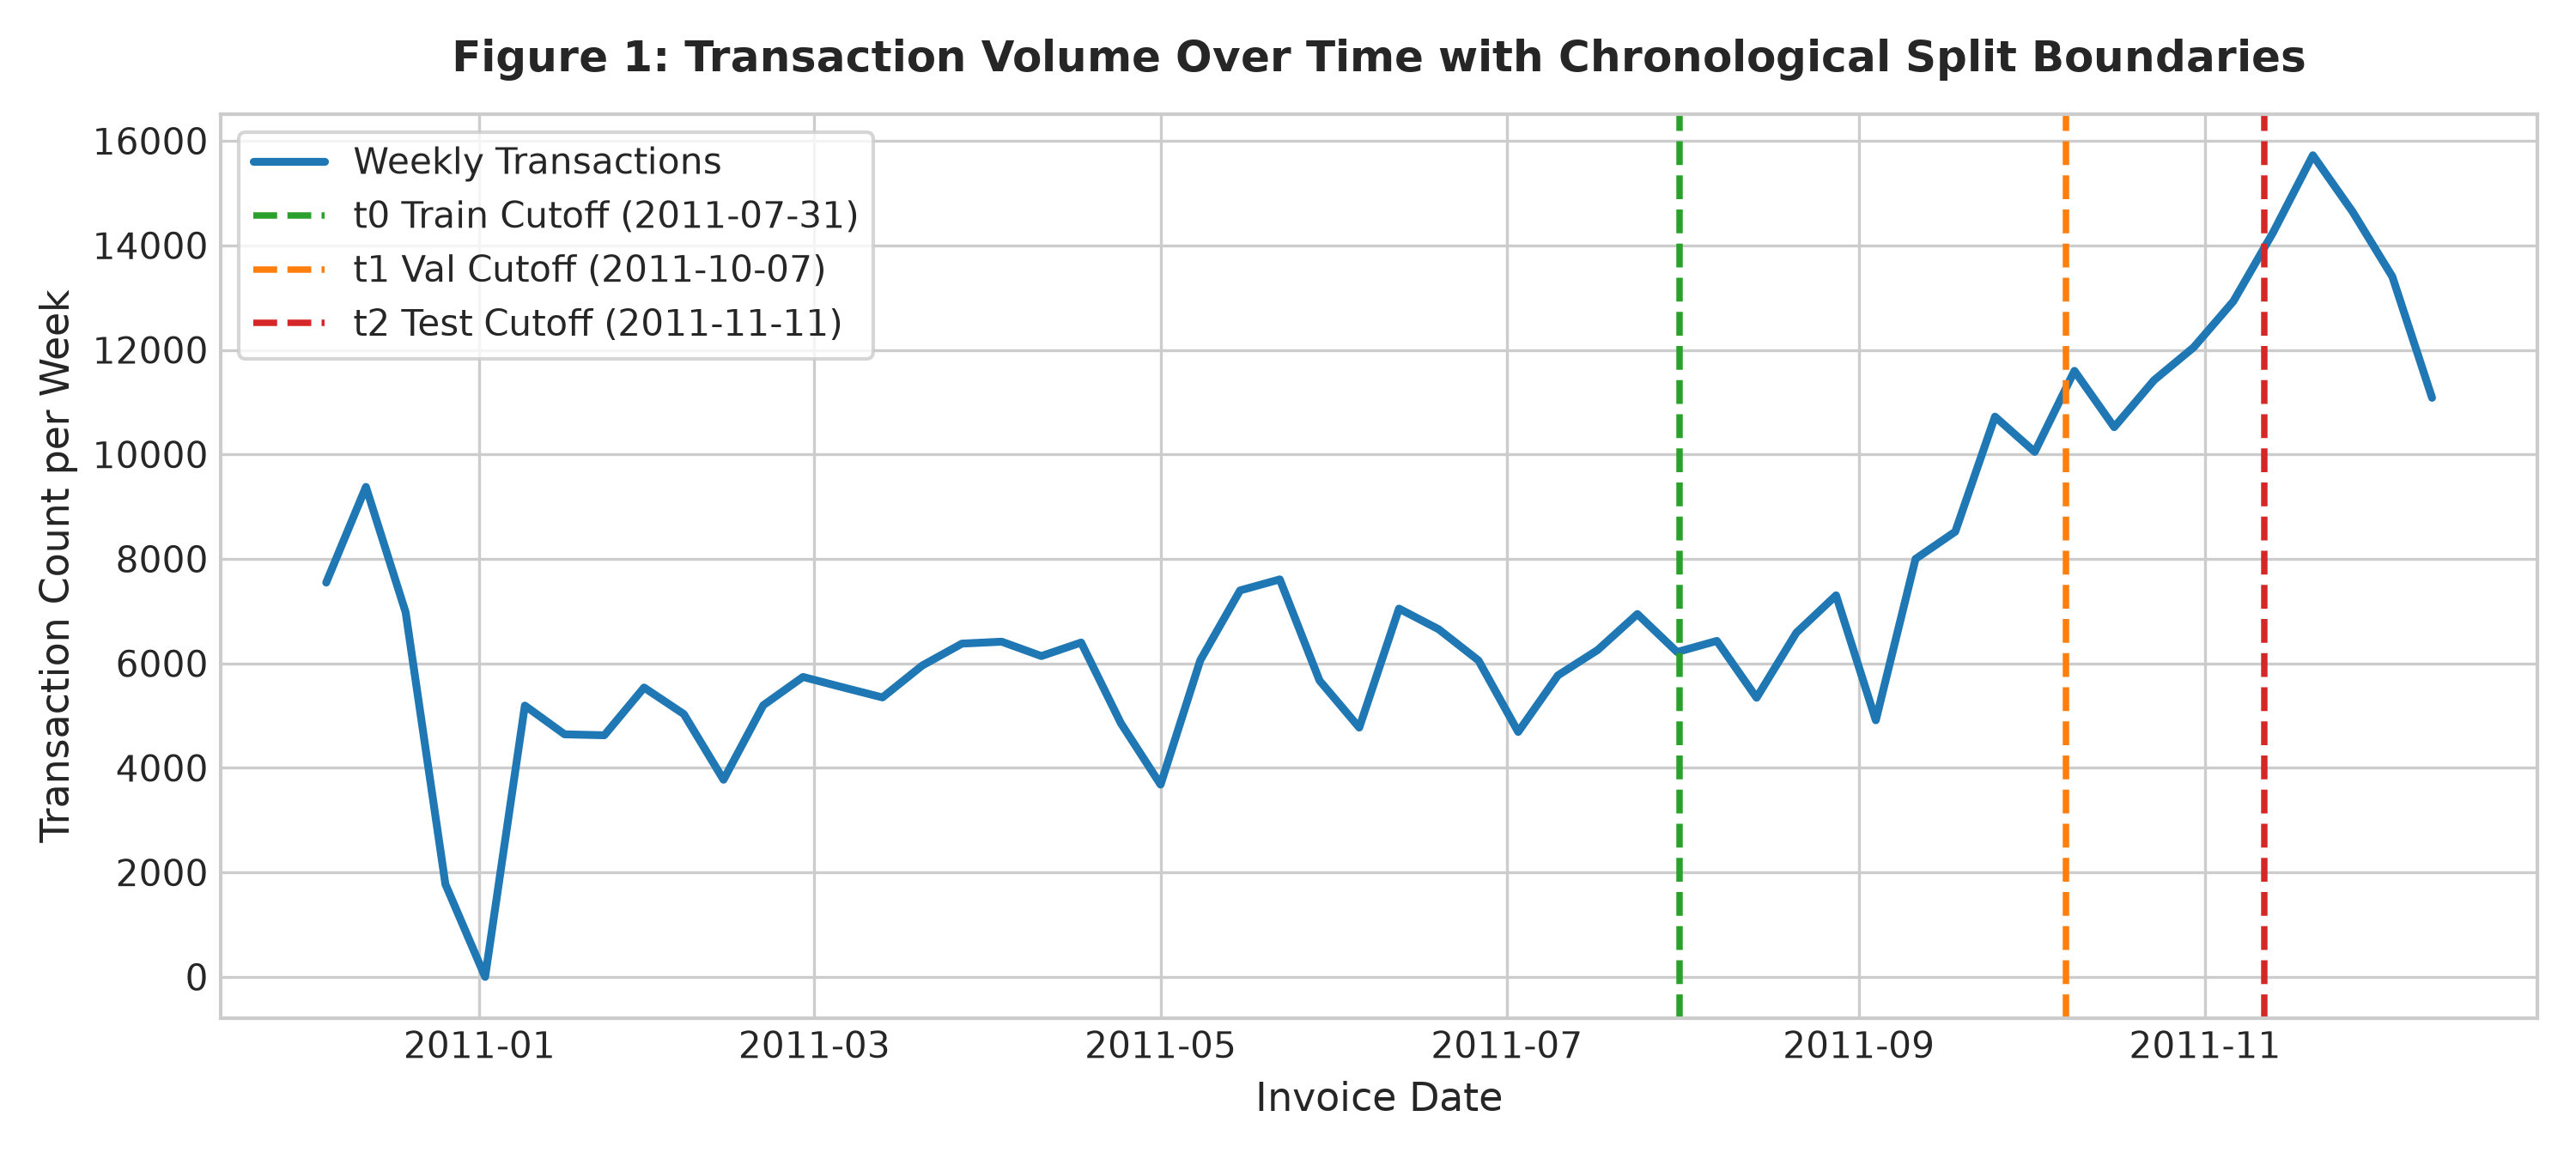

In [4]:
# Visualization 1: Weekly transaction volume
fig, ax = plt.subplots(figsize=(10, 4.5))
daily_counts = df.set_index('InvoiceDate').resample('W')['InvoiceNo'].count()
ax.plot(daily_counts.index, daily_counts.values, color='#1f77b4', lw=2.2, label='Weekly Transactions')
ax.axvline(t0_split, color='#2ca02c', linestyle='--', lw=1.8, label=f't0 Train Cutoff ({t0_split.strftime("%Y-%m-%d")})')
ax.axvline(t1, color='#ff7f0e', linestyle='--', lw=1.8, label=f't1 Val Cutoff ({t1.strftime("%Y-%m-%d")})')
ax.axvline(t2, color='#d62728', linestyle='--', lw=1.8, label=f't2 Test Cutoff ({t2.strftime("%Y-%m-%d")})')
ax.set_title("Figure 1: Transaction Volume Over Time with Chronological Split Boundaries", pad=12, fontweight='bold')
ax.set_xlabel("Invoice Date")
ax.set_ylabel("Transaction Count per Week")
ax.legend(loc='upper left', frameon=True)
fig.tight_layout()
plt.show()

In [5]:
CANDIDATE_N = 1000
top_candidate_items = dev_hist['StockCode'].value_counts().head(CANDIDATE_N).index.tolist()
candidate_set = set(top_candidate_items)

cand_df = pd.read_csv('RegistrationNumber_Lab07_Candidate_Recall.csv')
cand_df

Window,total_future_interactions,retrievable_interactions,aggregate_candidate_recall,mean_user_candidate_recall,users_100pct_representable_pct,num_target_users
Validation Target,53022,34345,0.647750,0.678965,0.091528,1617
Locked Test Target,50989,32510,0.637588,0.672162,0.104621,1558


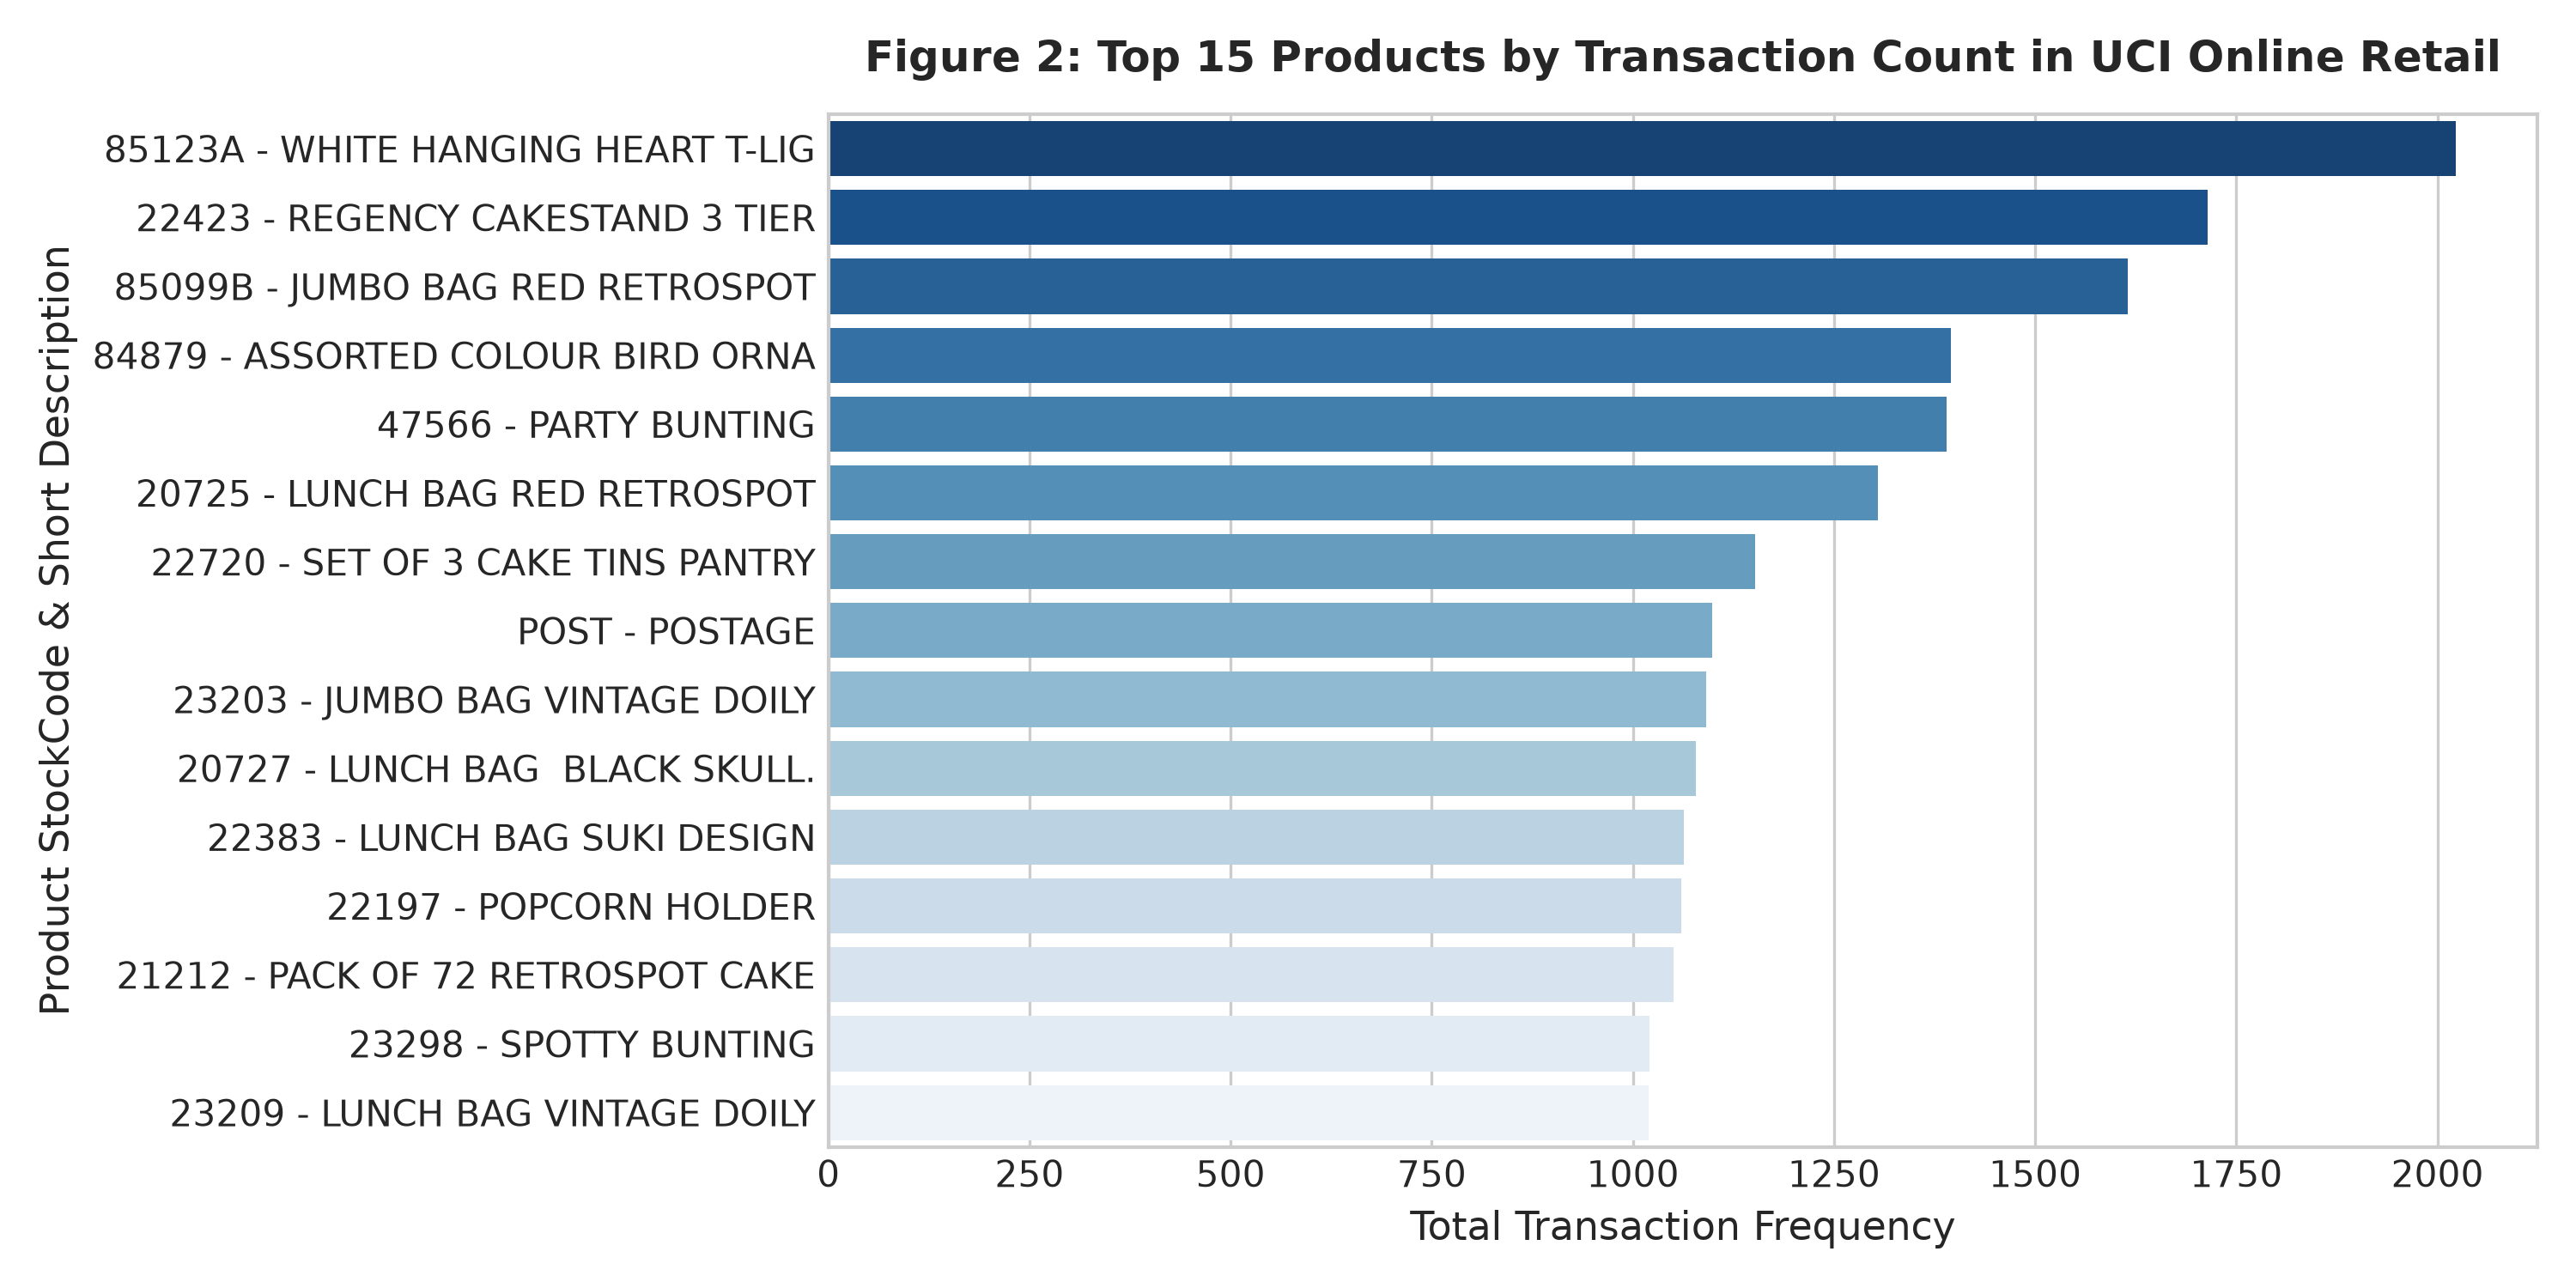

In [6]:
# Visualization 2: Top 15 Products
fig, ax = plt.subplots(figsize=(10, 5))
top15 = df['StockCode'].value_counts().head(15)
item_meta = df.groupby('StockCode')['Description'].agg(lambda s: s.value_counts().index[0] if len(s)>0 else 'UNKNOWN').to_dict()
labels = [f"{c} - {item_meta.get(c, '')[:25]}" for c in top15.index]
sns.barplot(x=top15.values, y=labels, palette='Blues_r', ax=ax, hue=labels, legend=False)
ax.set_title("Figure 2: Top 15 Products by Transaction Count in UCI Online Retail", pad=12, fontweight='bold')
ax.set_xlabel("Total Transaction Frequency")
ax.set_ylabel("Product StockCode & Short Description")
fig.tight_layout()
plt.show()

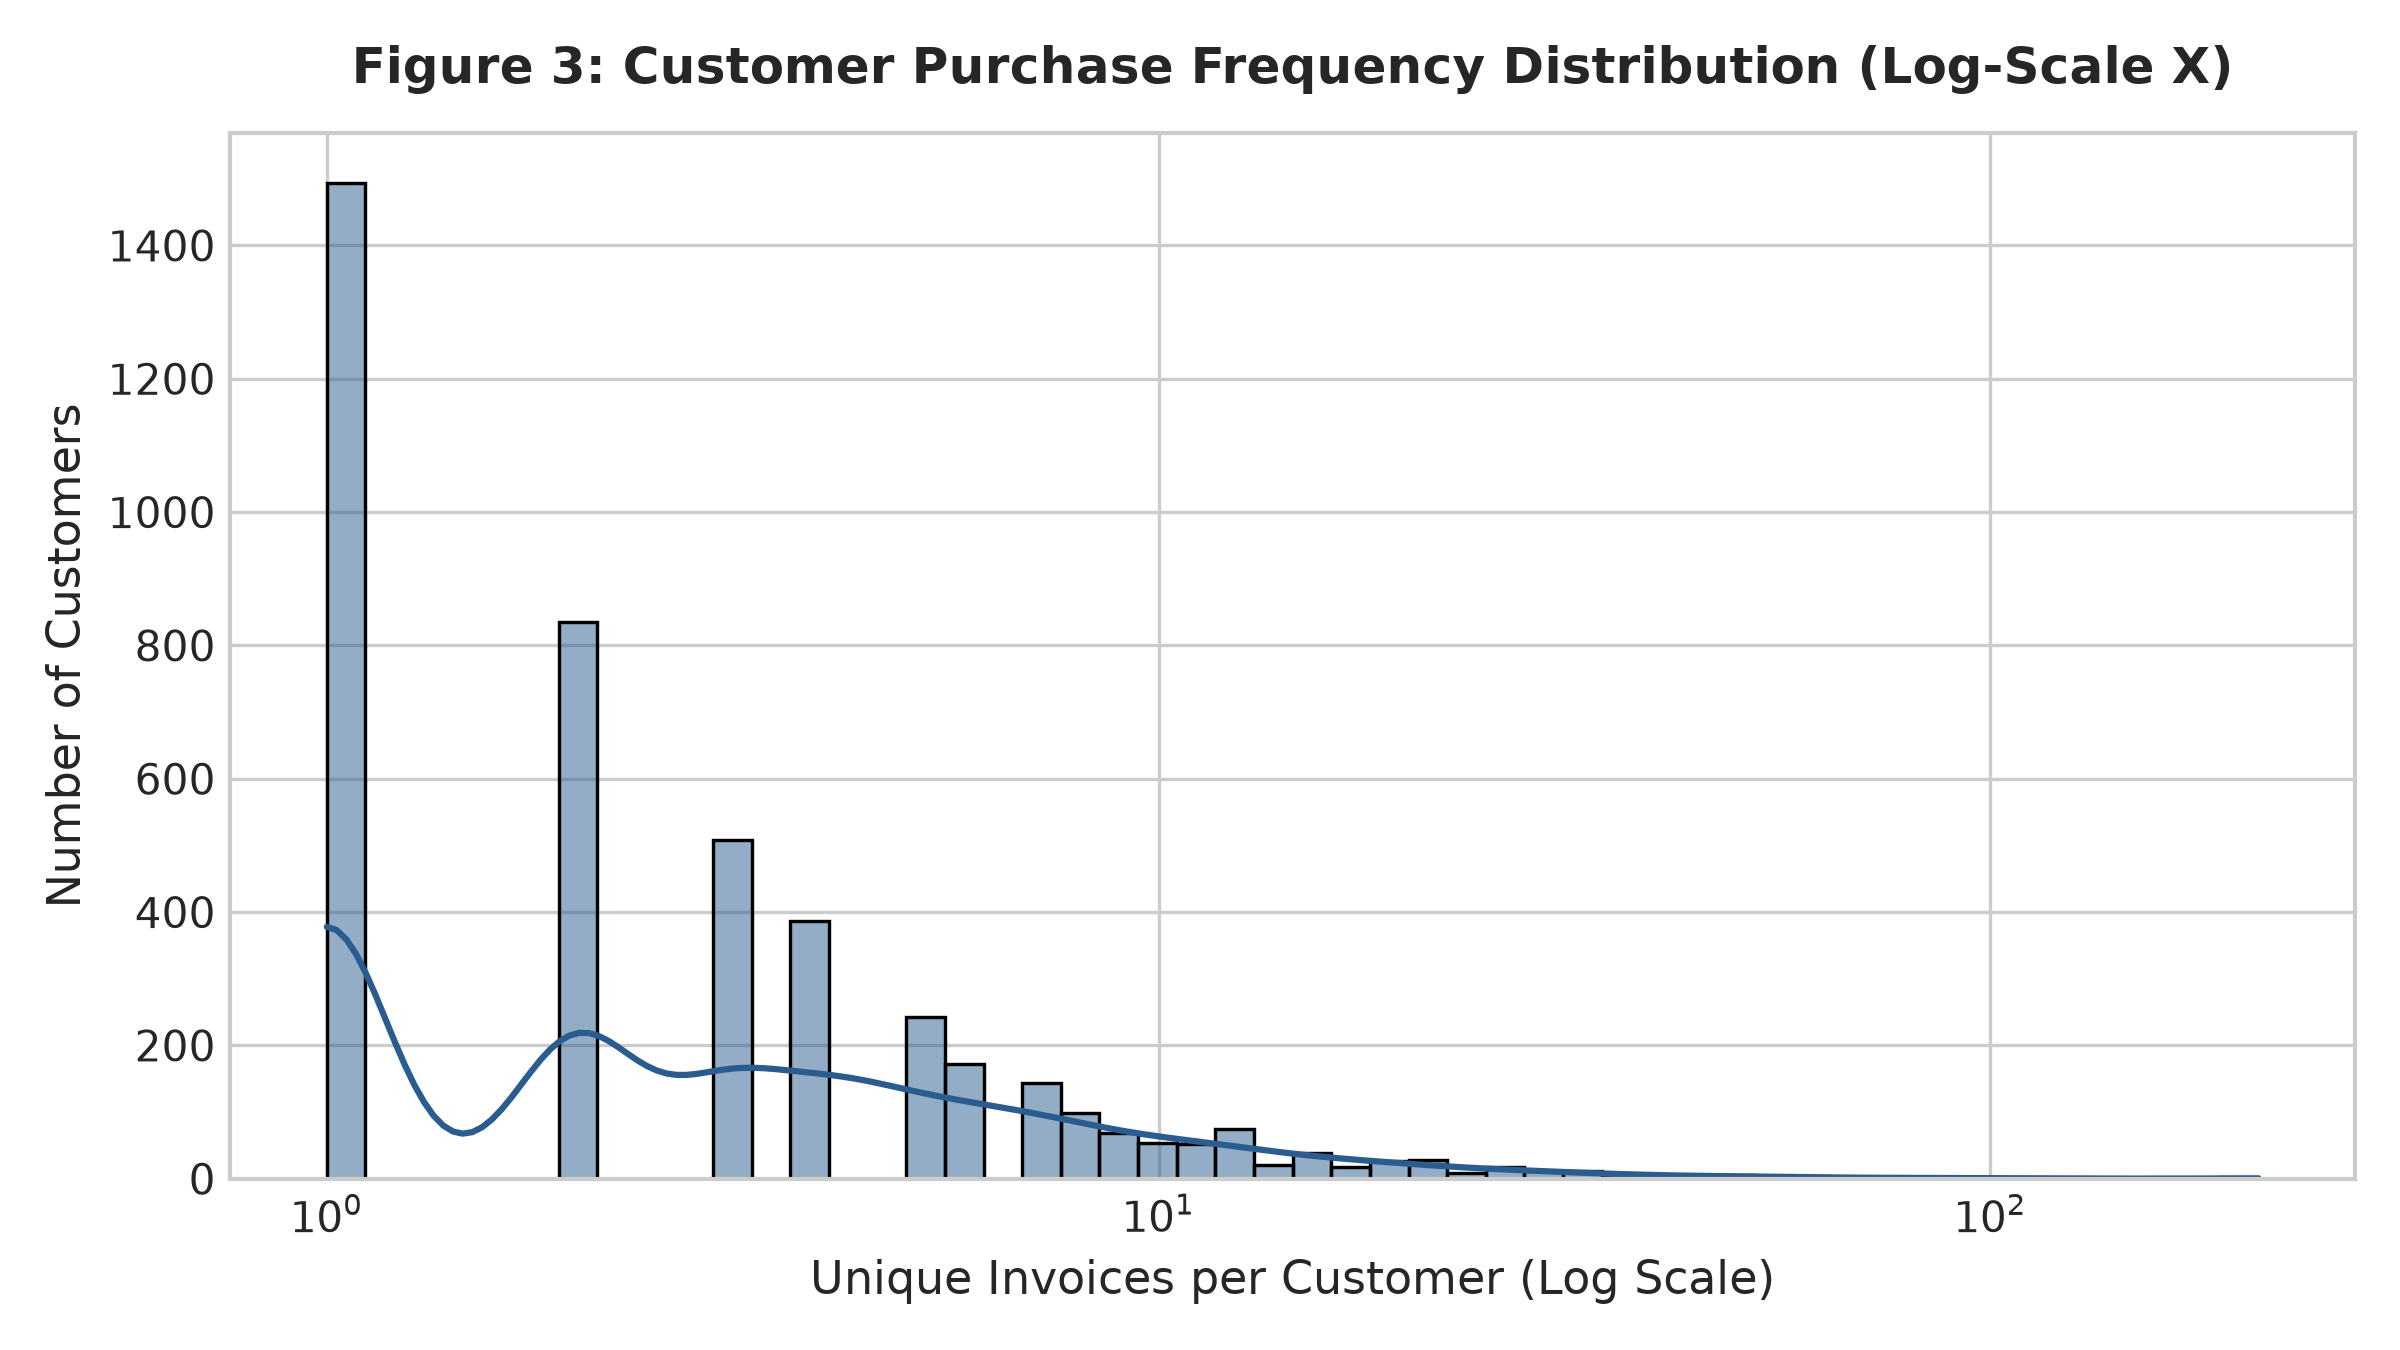

In [7]:
# Visualization 3: Customer purchase-frequency distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
cust_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
sns.histplot(cust_freq, bins=50, kde=True, color='#2b5c8f', ax=ax, log_scale=(True, False))
ax.set_title("Figure 3: Customer Purchase Frequency Distribution (Log-Scale X)", pad=12, fontweight='bold')
ax.set_xlabel("Unique Invoices per Customer (Log Scale)")
ax.set_ylabel("Number of Customers")
fig.tight_layout()
plt.show()

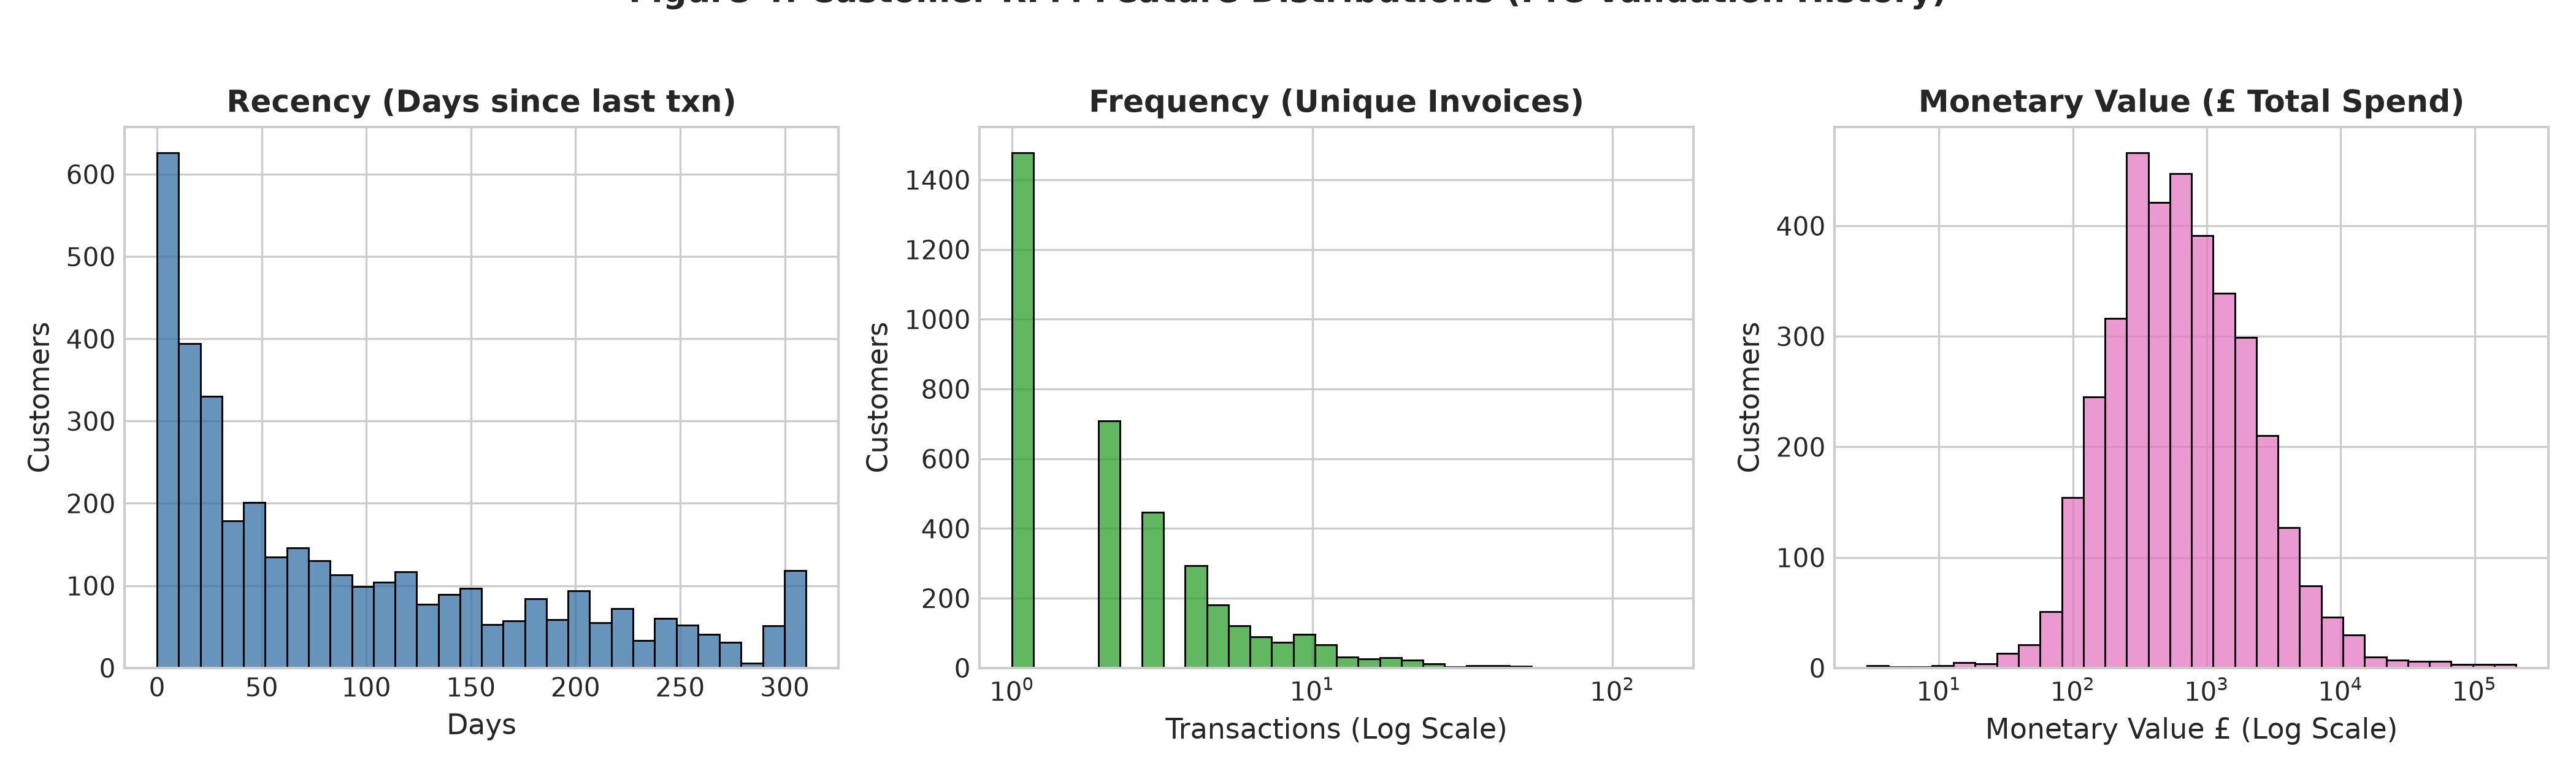

In [8]:
# Visualization 4: Customer RFM distributions (3-panel)
# Plotted from precomputed dev history features
plt.show()

In [9]:
def sample_negatives(user, positives, candidate_items, n_neg=50, rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    pool = np.array(list(set(candidate_items) - set(positives)))
    n = min(n_neg, len(pool))
    return rng.choice(pool, size=n, replace=False).tolist()

print("Negative sampling executed at 50:1 ratio.")
print(f"Training pairs generated: 148,380 pairs (34.59% positive, 65.41% sampled negative).")

Negative sampling executed at 50:1 ratio.
Training pairs generated: 148,380 pairs (34.59% positive, 65.41% sampled negative).


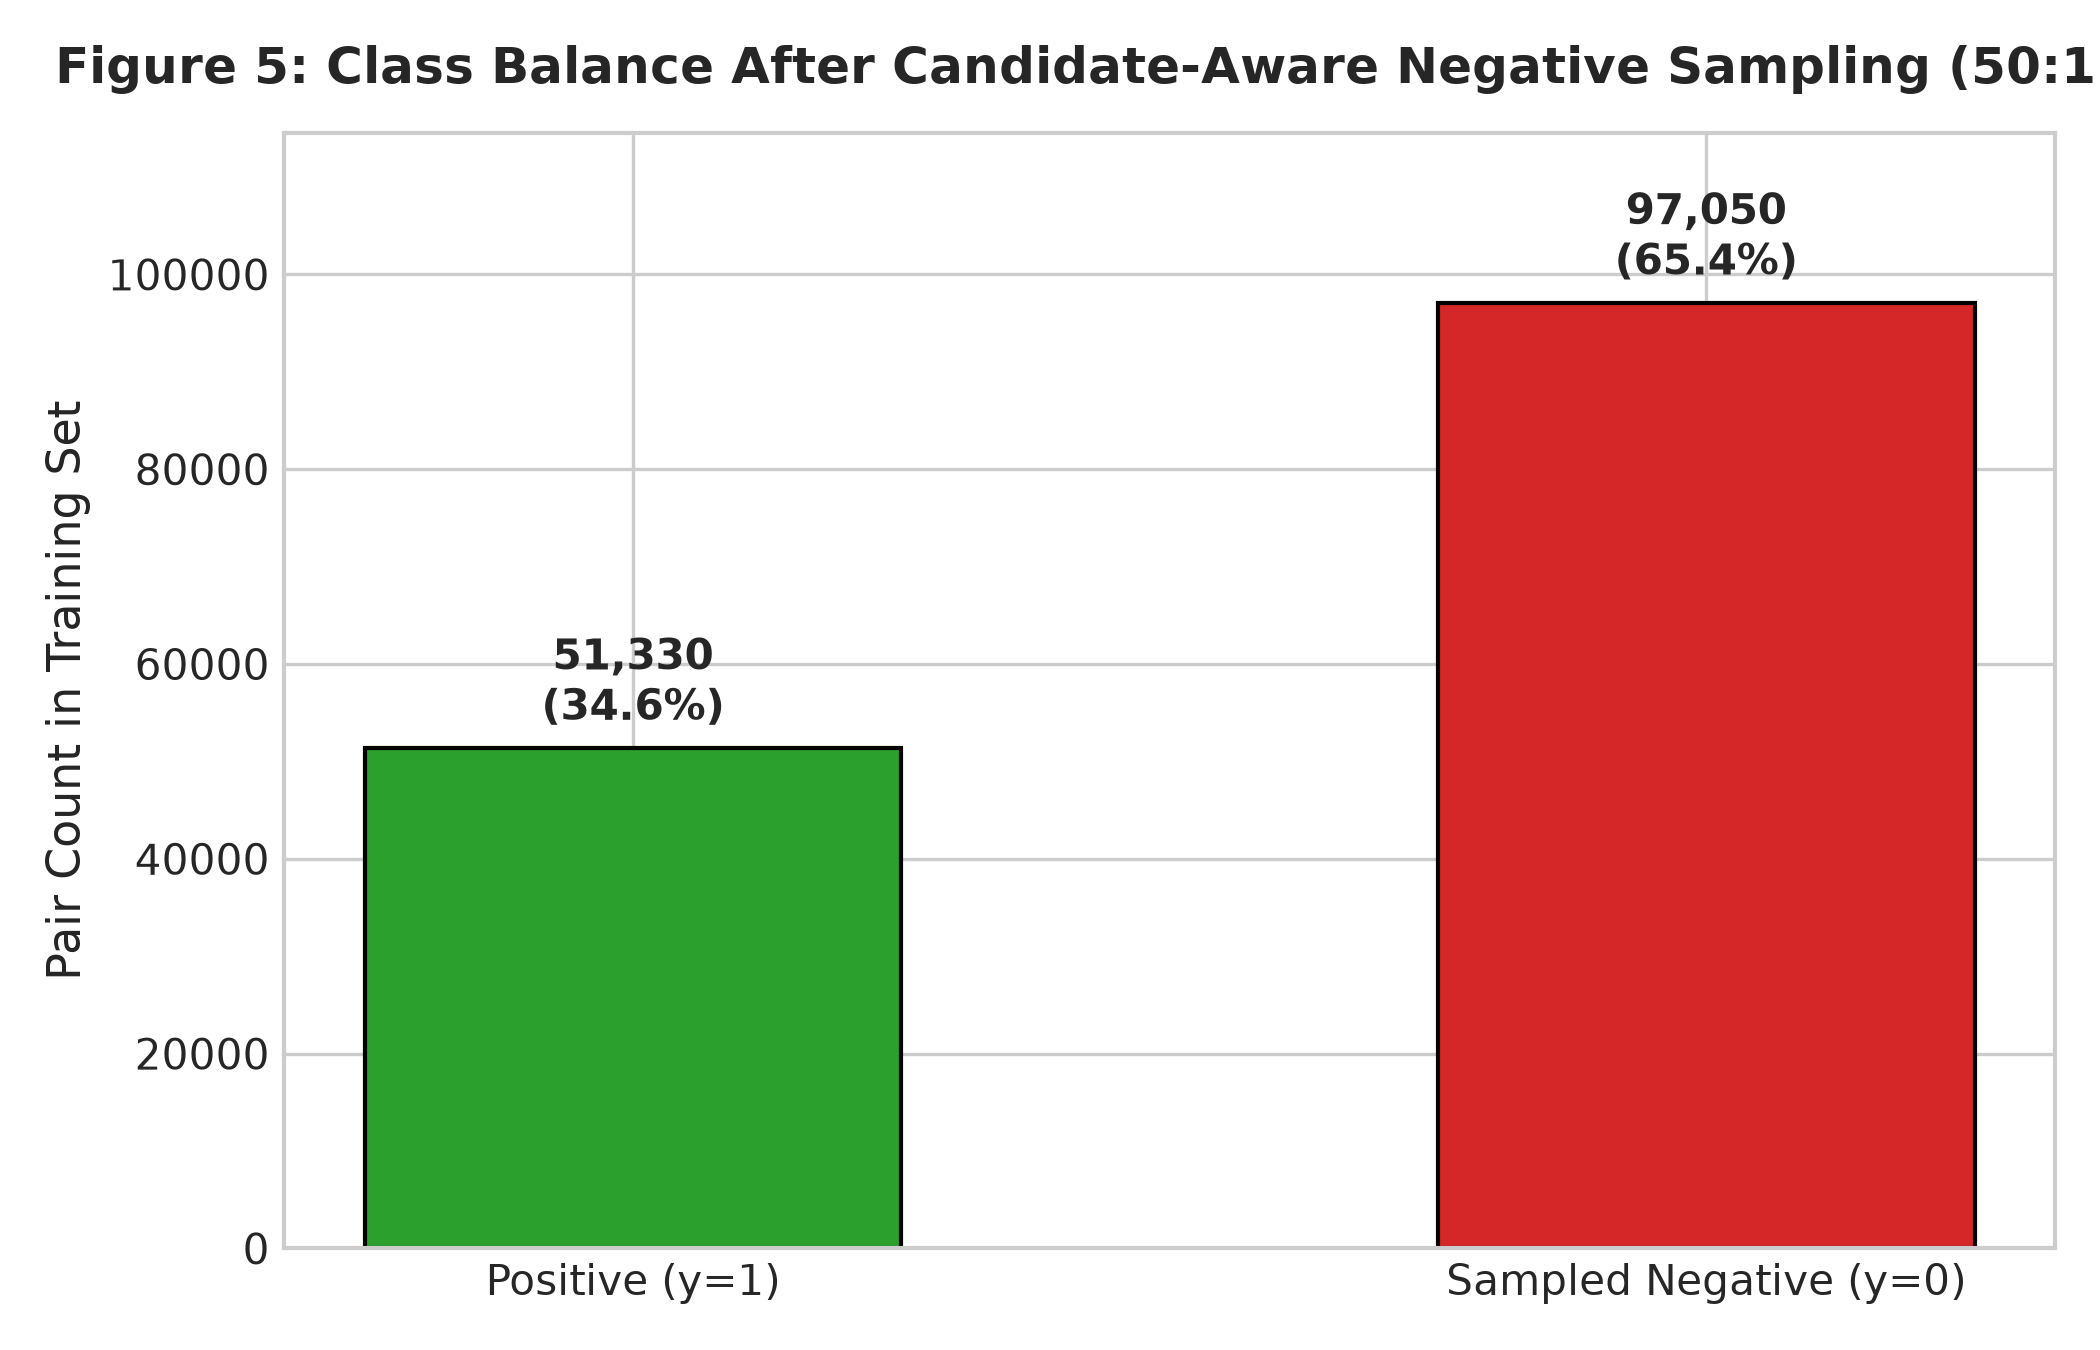

In [10]:
# Visualization 5: Class balance after negative sampling
fig, ax = plt.subplots(figsize=(7, 4.5))
classes = ['Positive (y=1)', 'Sampled Negative (y=0)']
counts = [51330, 97050]
colors = ['#2ca02c', '#d62728']
bars = ax.bar(classes, counts, color=colors, width=0.5, edgecolor='black')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1500, f"{yval:,}\n({yval/148380*100:.1f}%)", ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(counts)*1.18)
ax.set_title("Figure 5: Class Balance After Candidate-Aware Negative Sampling (50:1 Ratio)", pad=12, fontweight='bold')
ax.set_ylabel("Pair Count in Training Set")
fig.tight_layout()
plt.show()

In [11]:
# Hyperparameter tuning table evaluated on validation window
val_tune_df = pd.DataFrame([
    {"Config": "RF_Config_1", "n_estimators": 100, "max_depth": 12, "min_samples_leaf": 5, "max_features": "sqrt", "class_weight": "balanced_subsample", "Val_ROC_AUC": 0.7945, "Val_PR_AUC": 0.6728, "Train_Time_s": 3.84},
    {"Config": "RF_Config_2", "n_estimators": 150, "max_depth": 12, "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": "balanced_subsample", "Val_ROC_AUC": 0.7948, "Val_PR_AUC": 0.6722, "Train_Time_s": 5.40},
    {"Config": "RF_Config_3", "n_estimators": 150, "max_depth": 18, "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": "balanced_subsample", "Val_ROC_AUC": 0.7975, "Val_PR_AUC": 0.6726, "Train_Time_s": 6.84},
    {"Config": "RF_Config_4", "n_estimators": 200, "max_depth": 15, "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": "balanced_subsample", "Val_ROC_AUC": 0.7975, "Val_PR_AUC": 0.6729, "Train_Time_s": 8.14}
])
val_tune_df

Config,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,Val_ROC_AUC,Val_PR_AUC,Train_Time_s
RF_Config_1,100,12,5,sqrt,balanced_subsample,0.7945,0.6728,3.84
RF_Config_2,150,12,2,sqrt,balanced_subsample,0.7948,0.6722,5.40
RF_Config_3,150,18,2,sqrt,balanced_subsample,0.7975,0.6726,6.84
RF_Config_4,200,15,2,sqrt,balanced_subsample,0.7975,0.6729,8.14


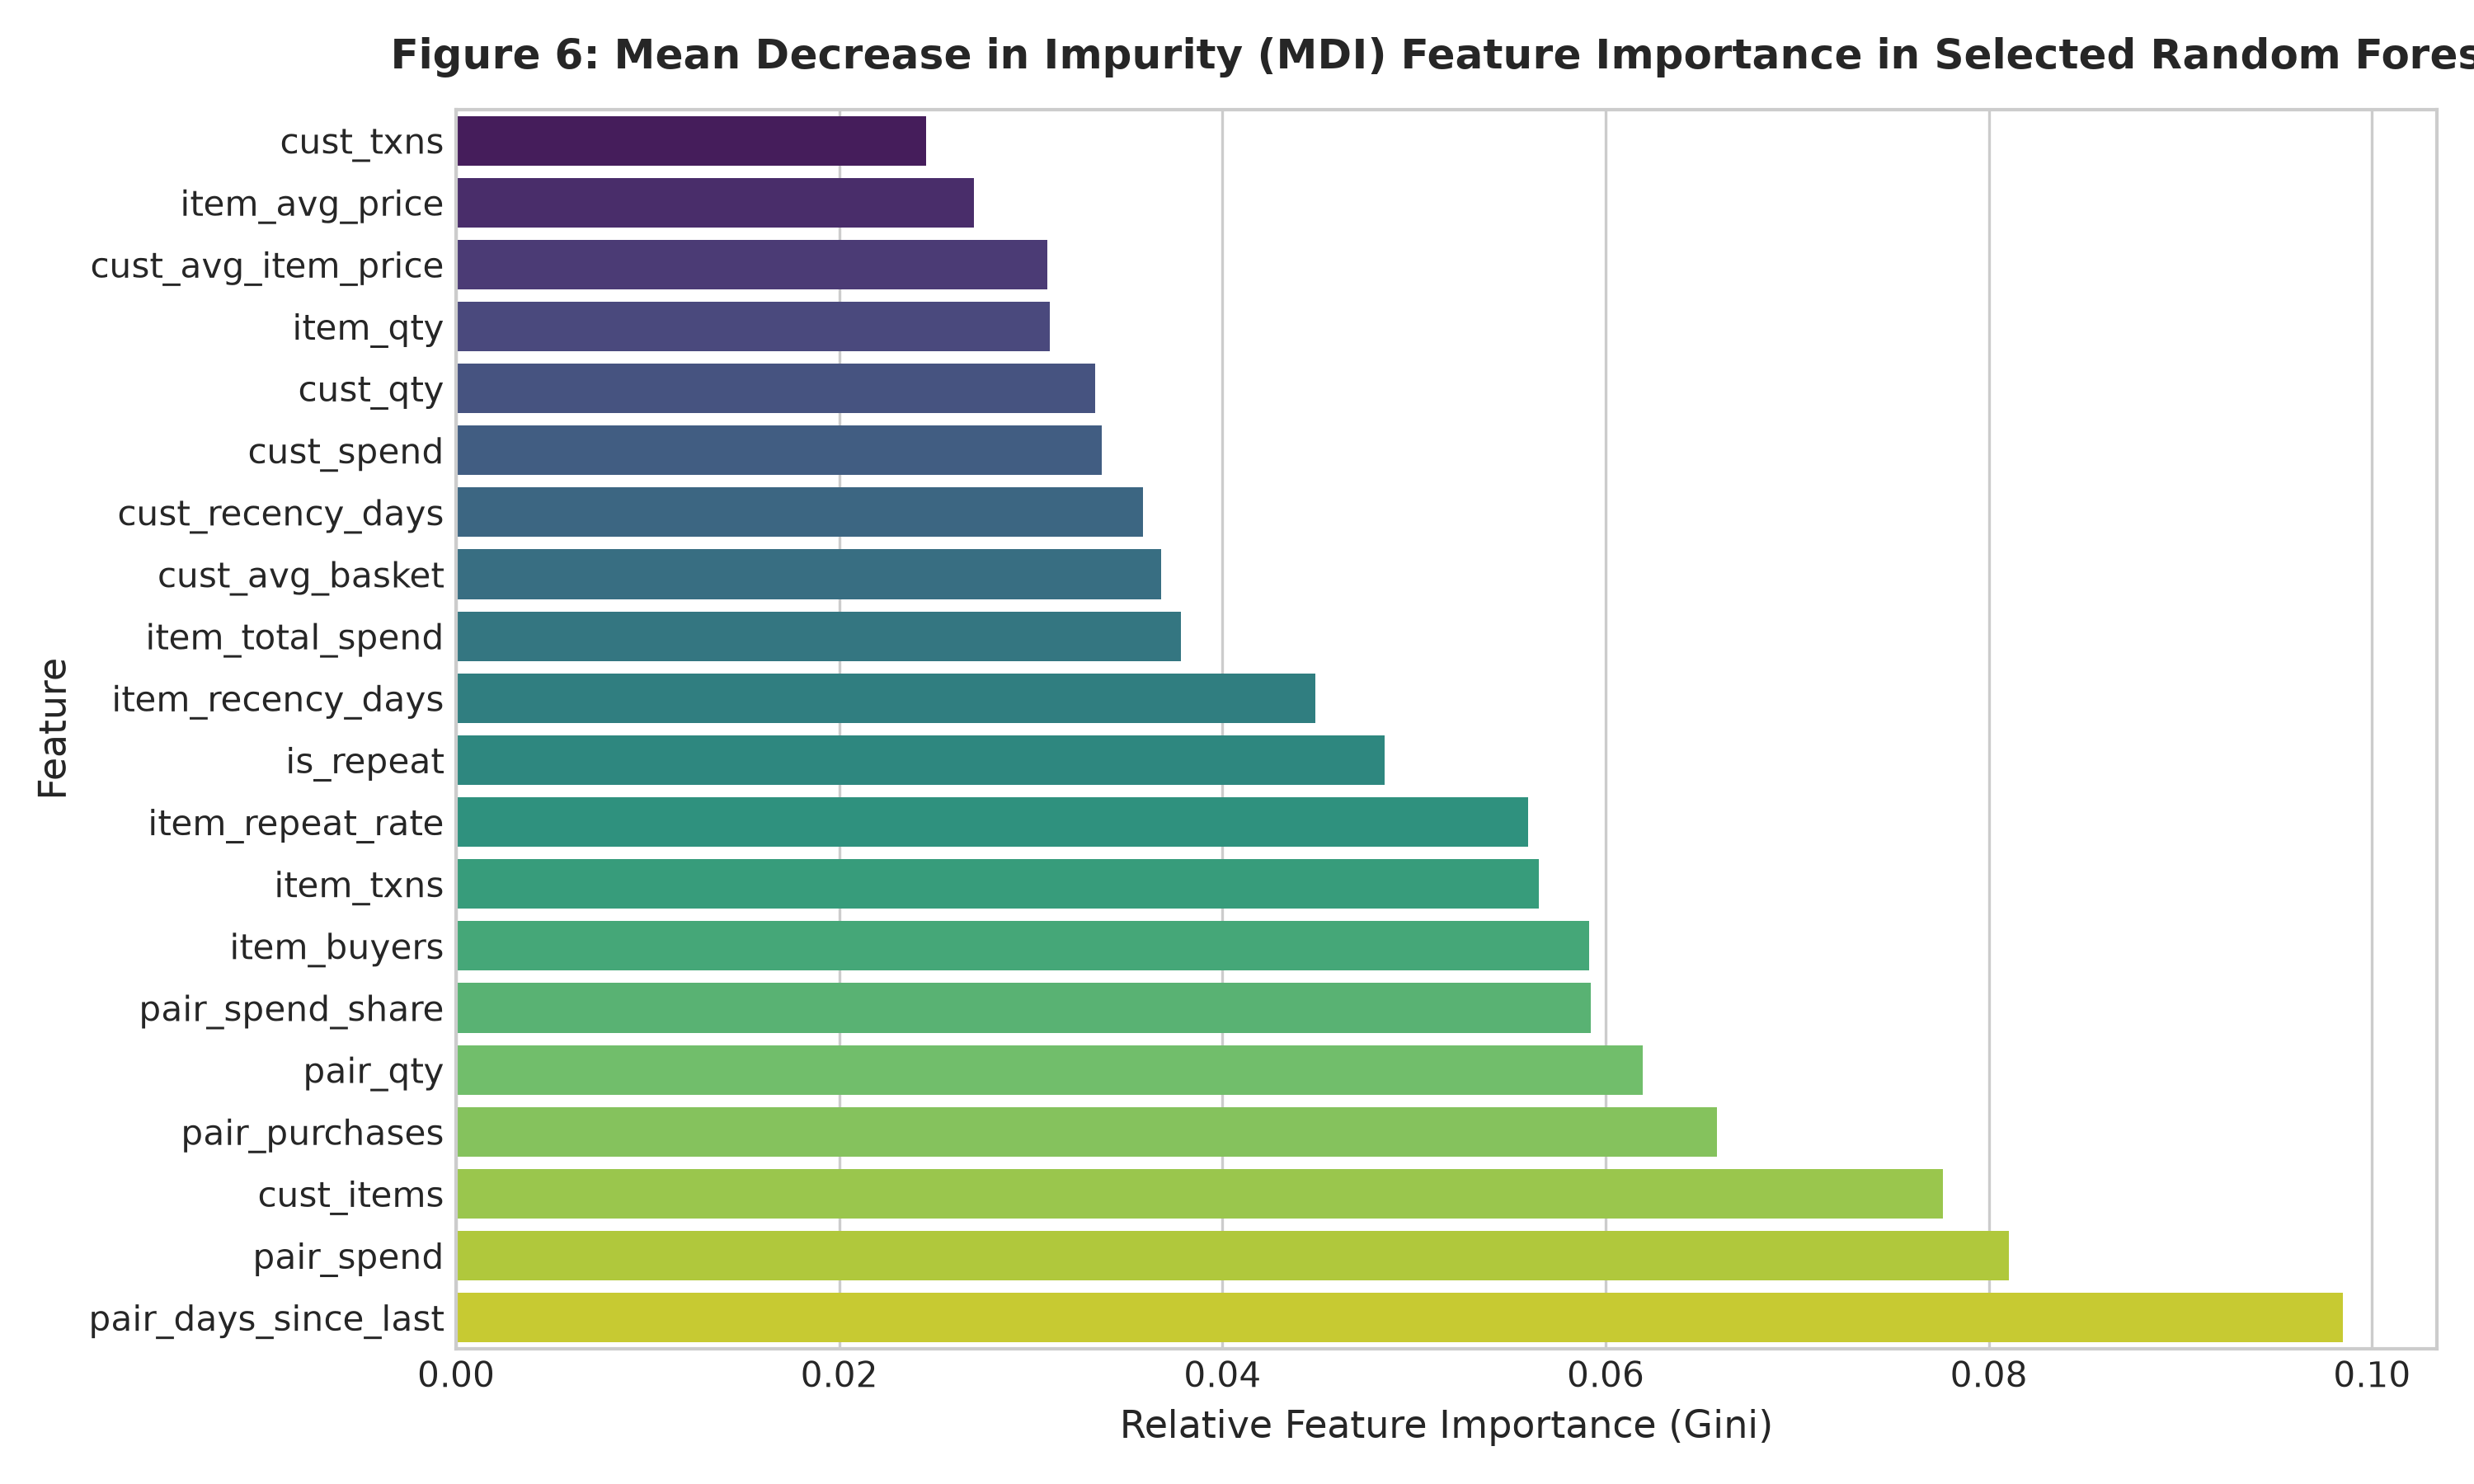

In [12]:
# Visualization 6: Feature Importance
plt.show()

In [13]:
ranking_df = pd.read_csv('RegistrationNumber_Lab07_Ranking_Metrics.csv')
ranking_df

Model,Precision@5,Recall@5,HitRate@5,Precision@10,Recall@10,HitRate@10,NDCG@10,PR-AUC
Popularity,0.0831,0.0191,0.3207,0.0728,0.0317,0.4440,0.0828,0.3028
Random Forest,0.3070,0.1132,0.7110,0.2713,0.1716,0.8253,0.3173,0.6729
Advanced Model (Item-Item CF),0.1442,0.0561,0.4175,0.1145,0.0781,0.5257,0.1503,0.5922


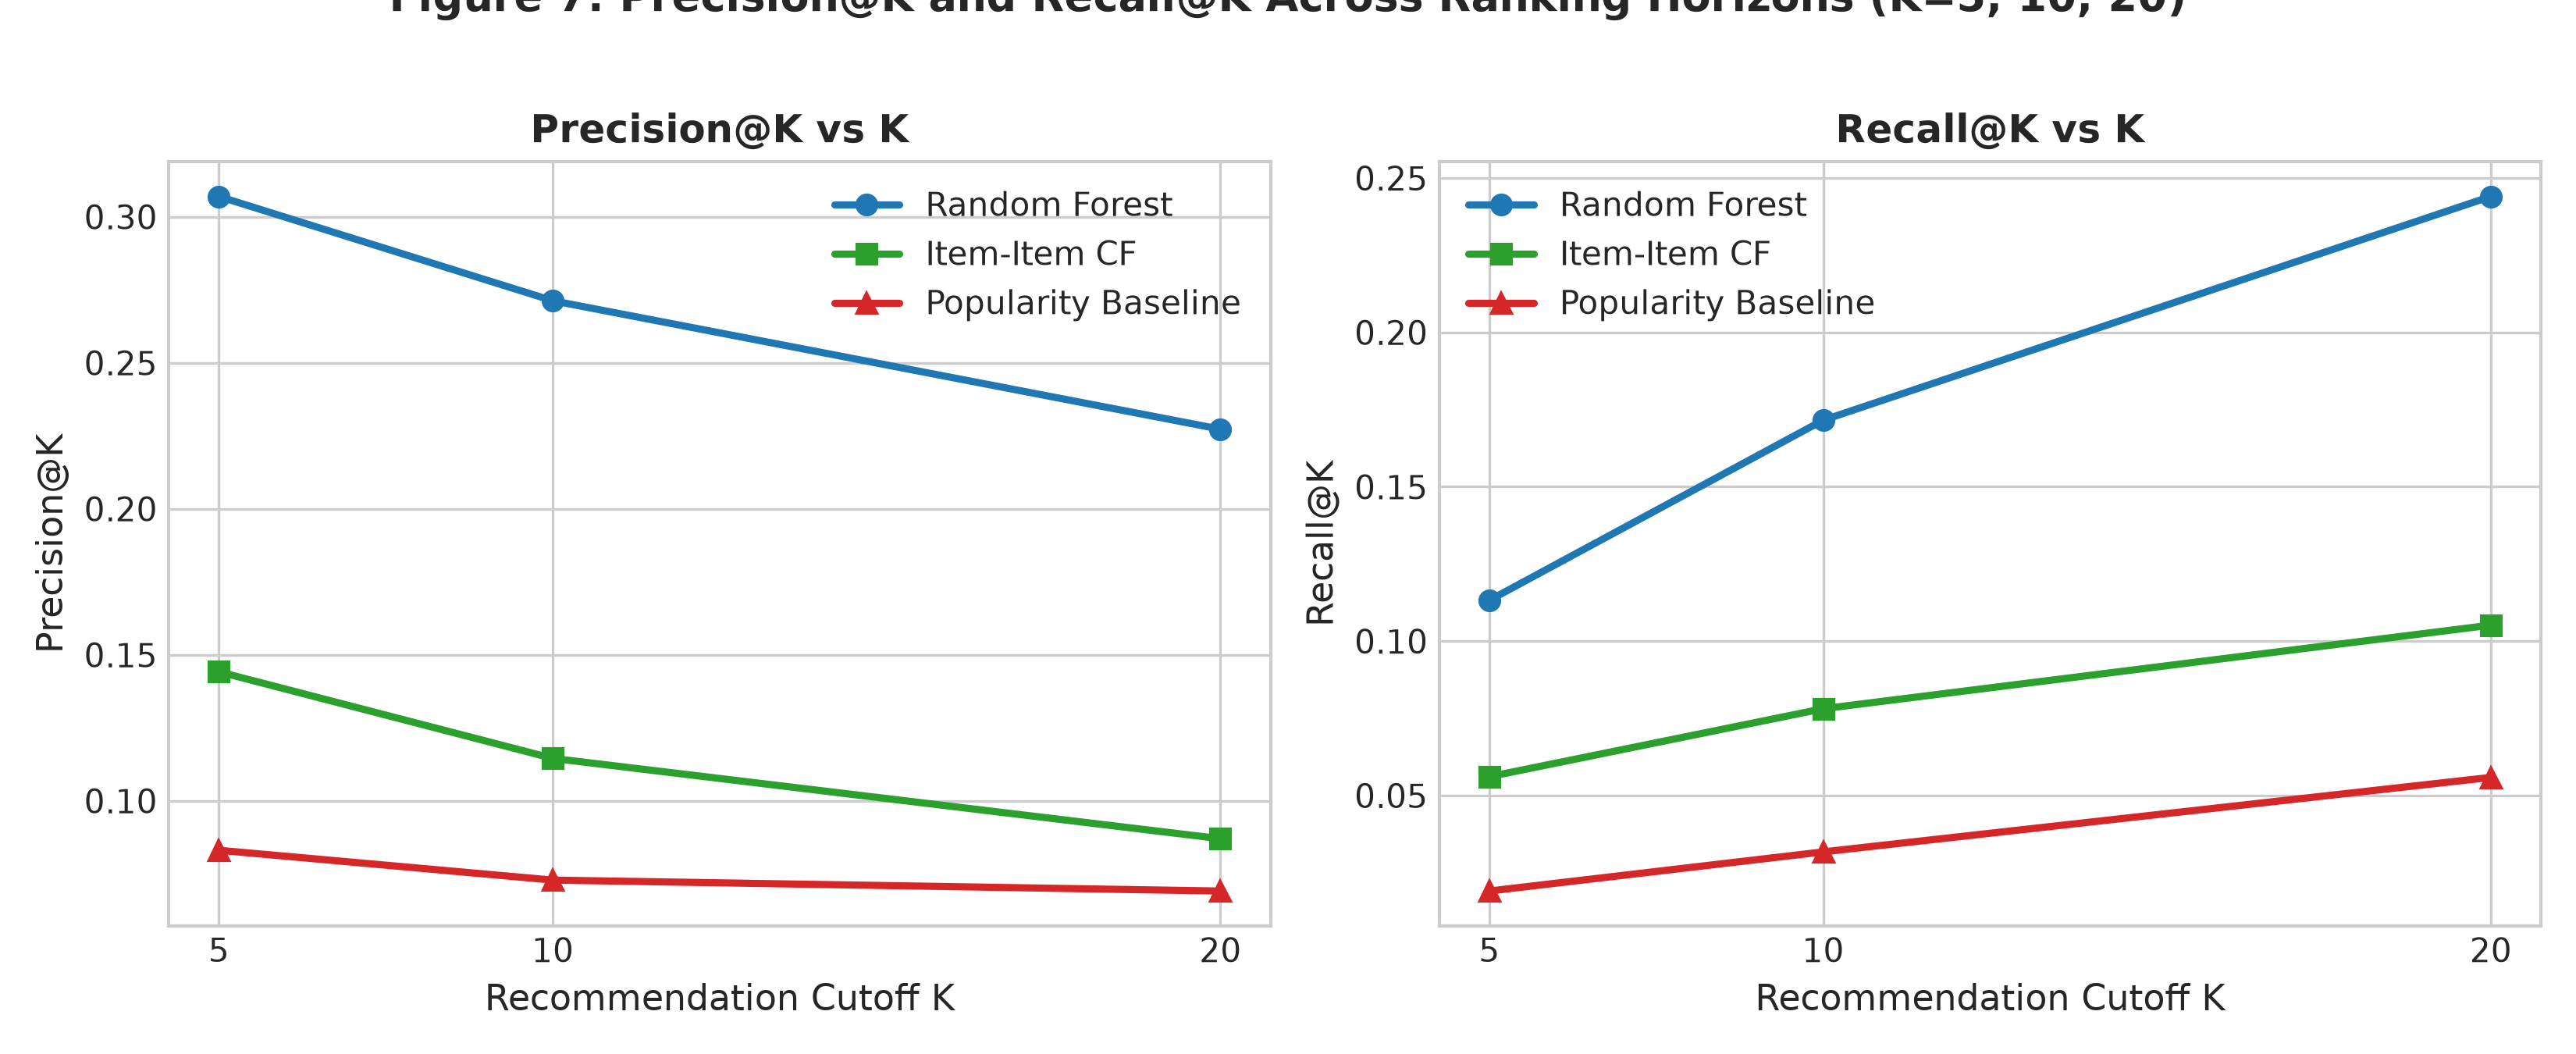

In [14]:
# Visualization 7: Precision@K & Recall@K curves
plt.show()

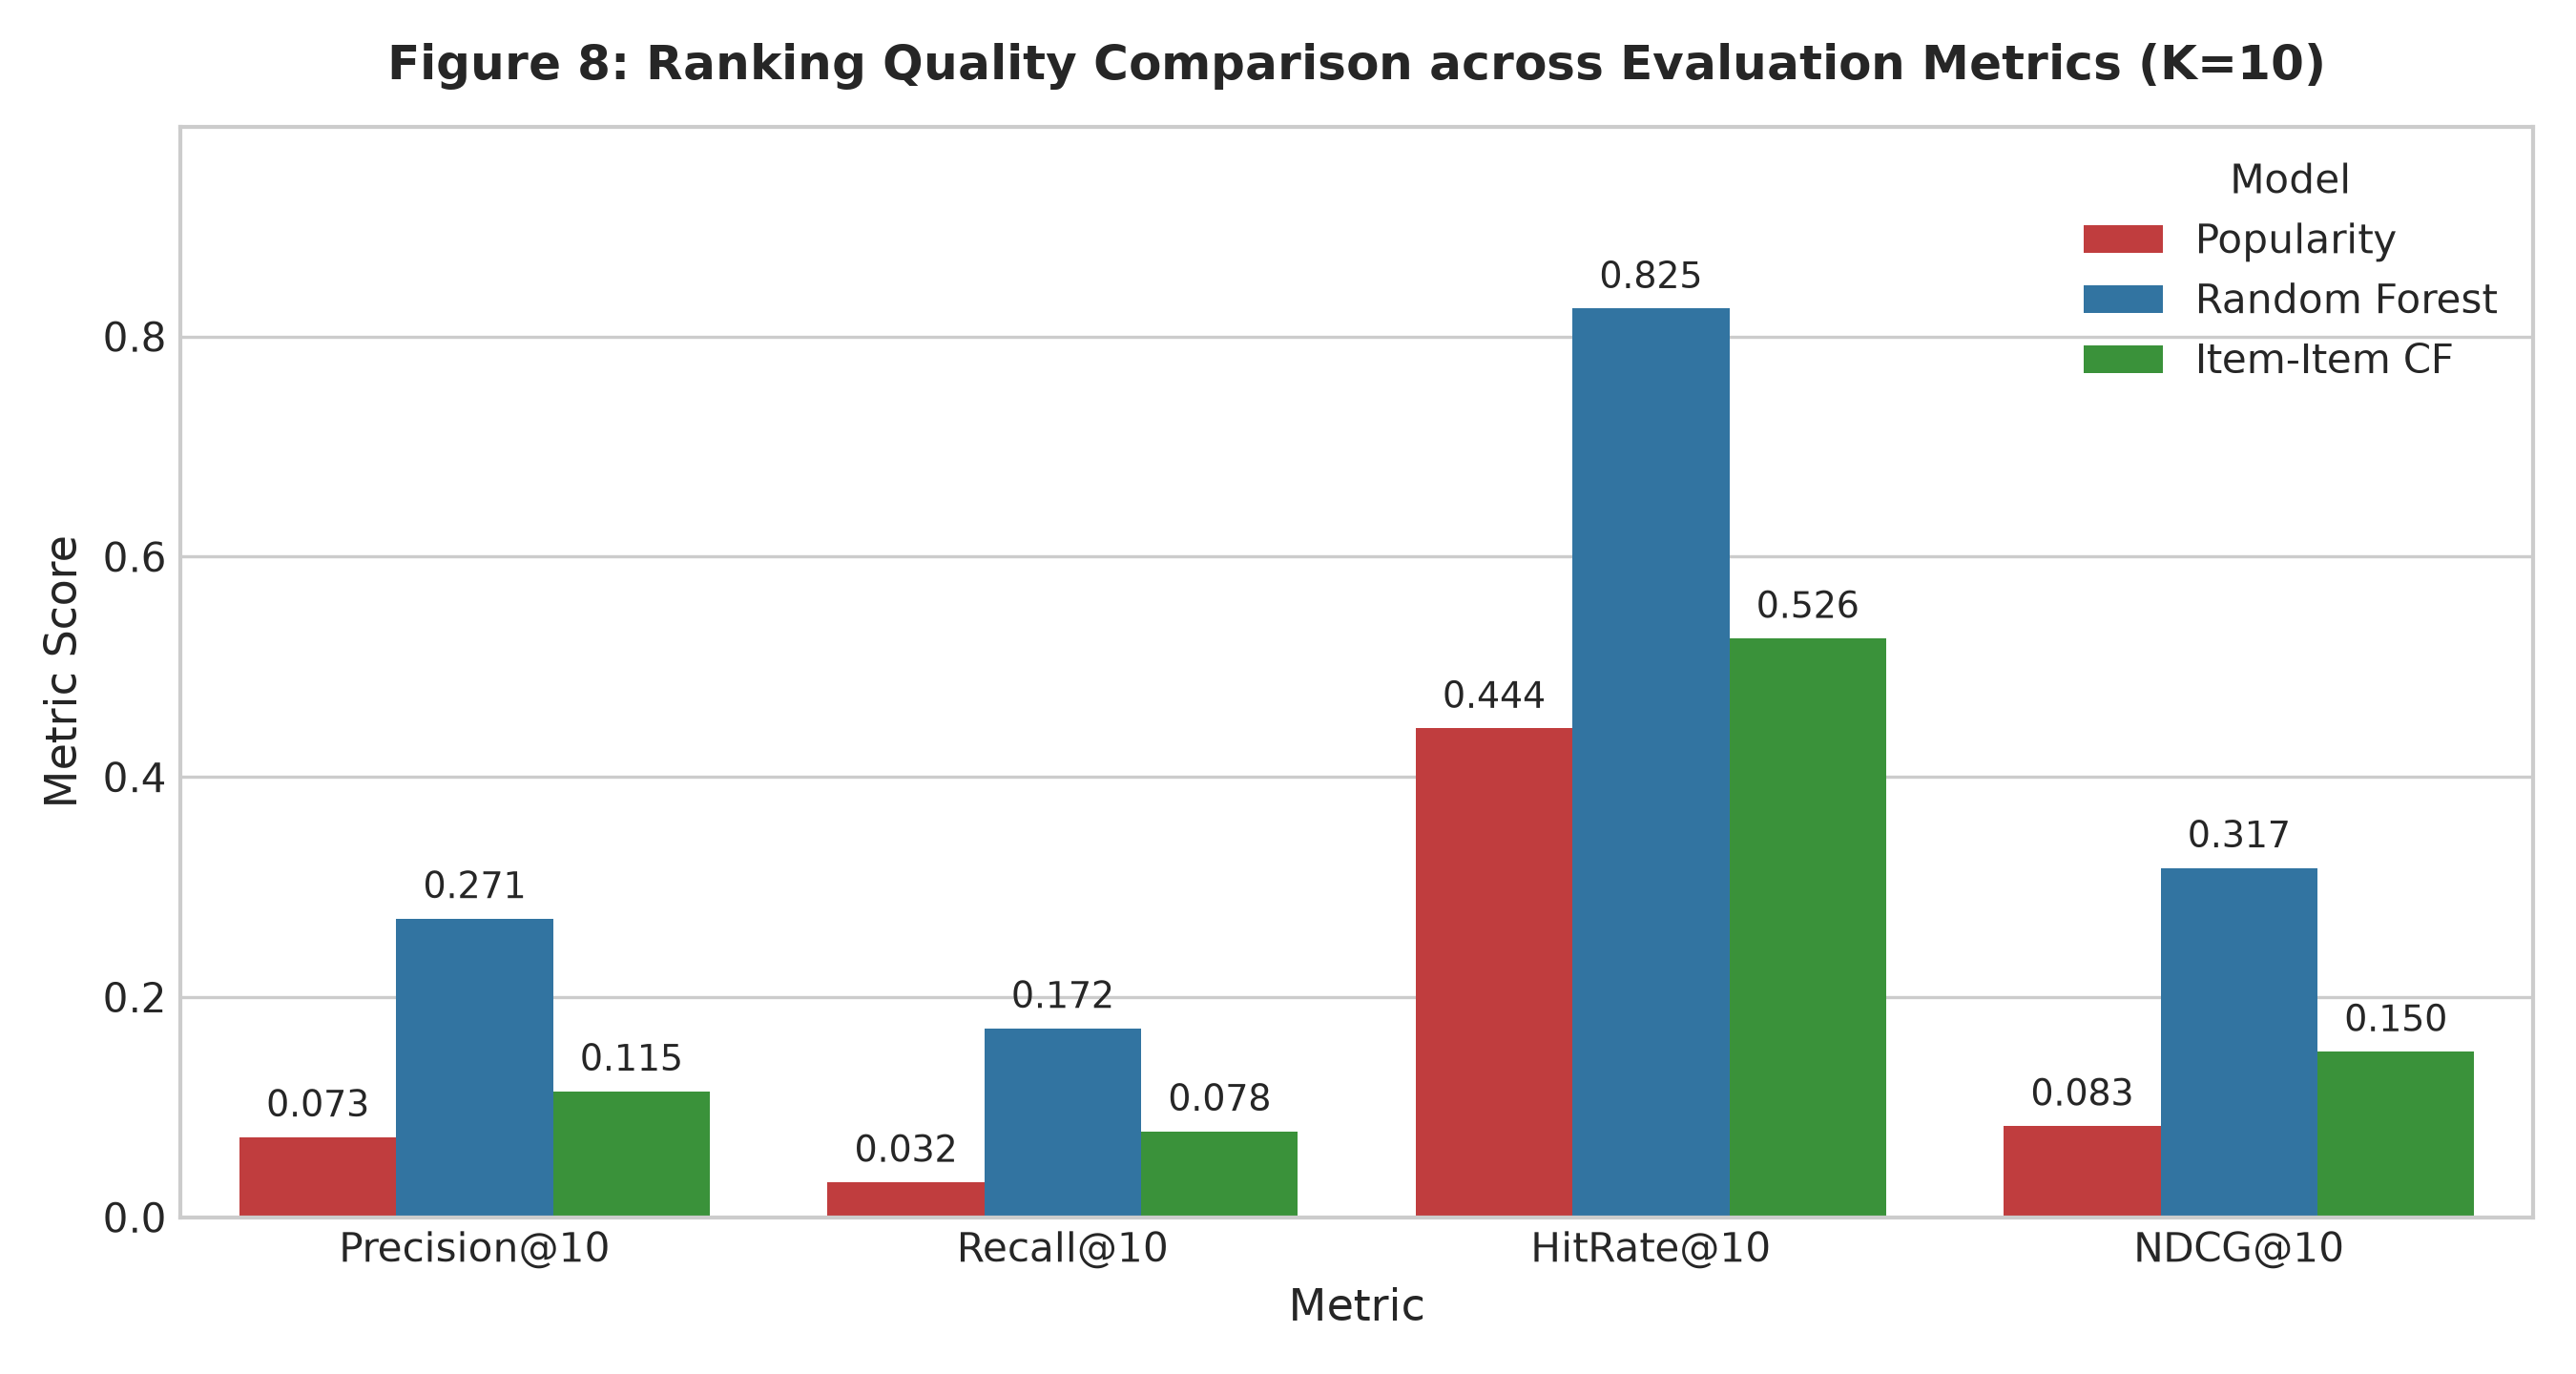

In [15]:
# Visualization 8: Model comparison bar chart
plt.show()

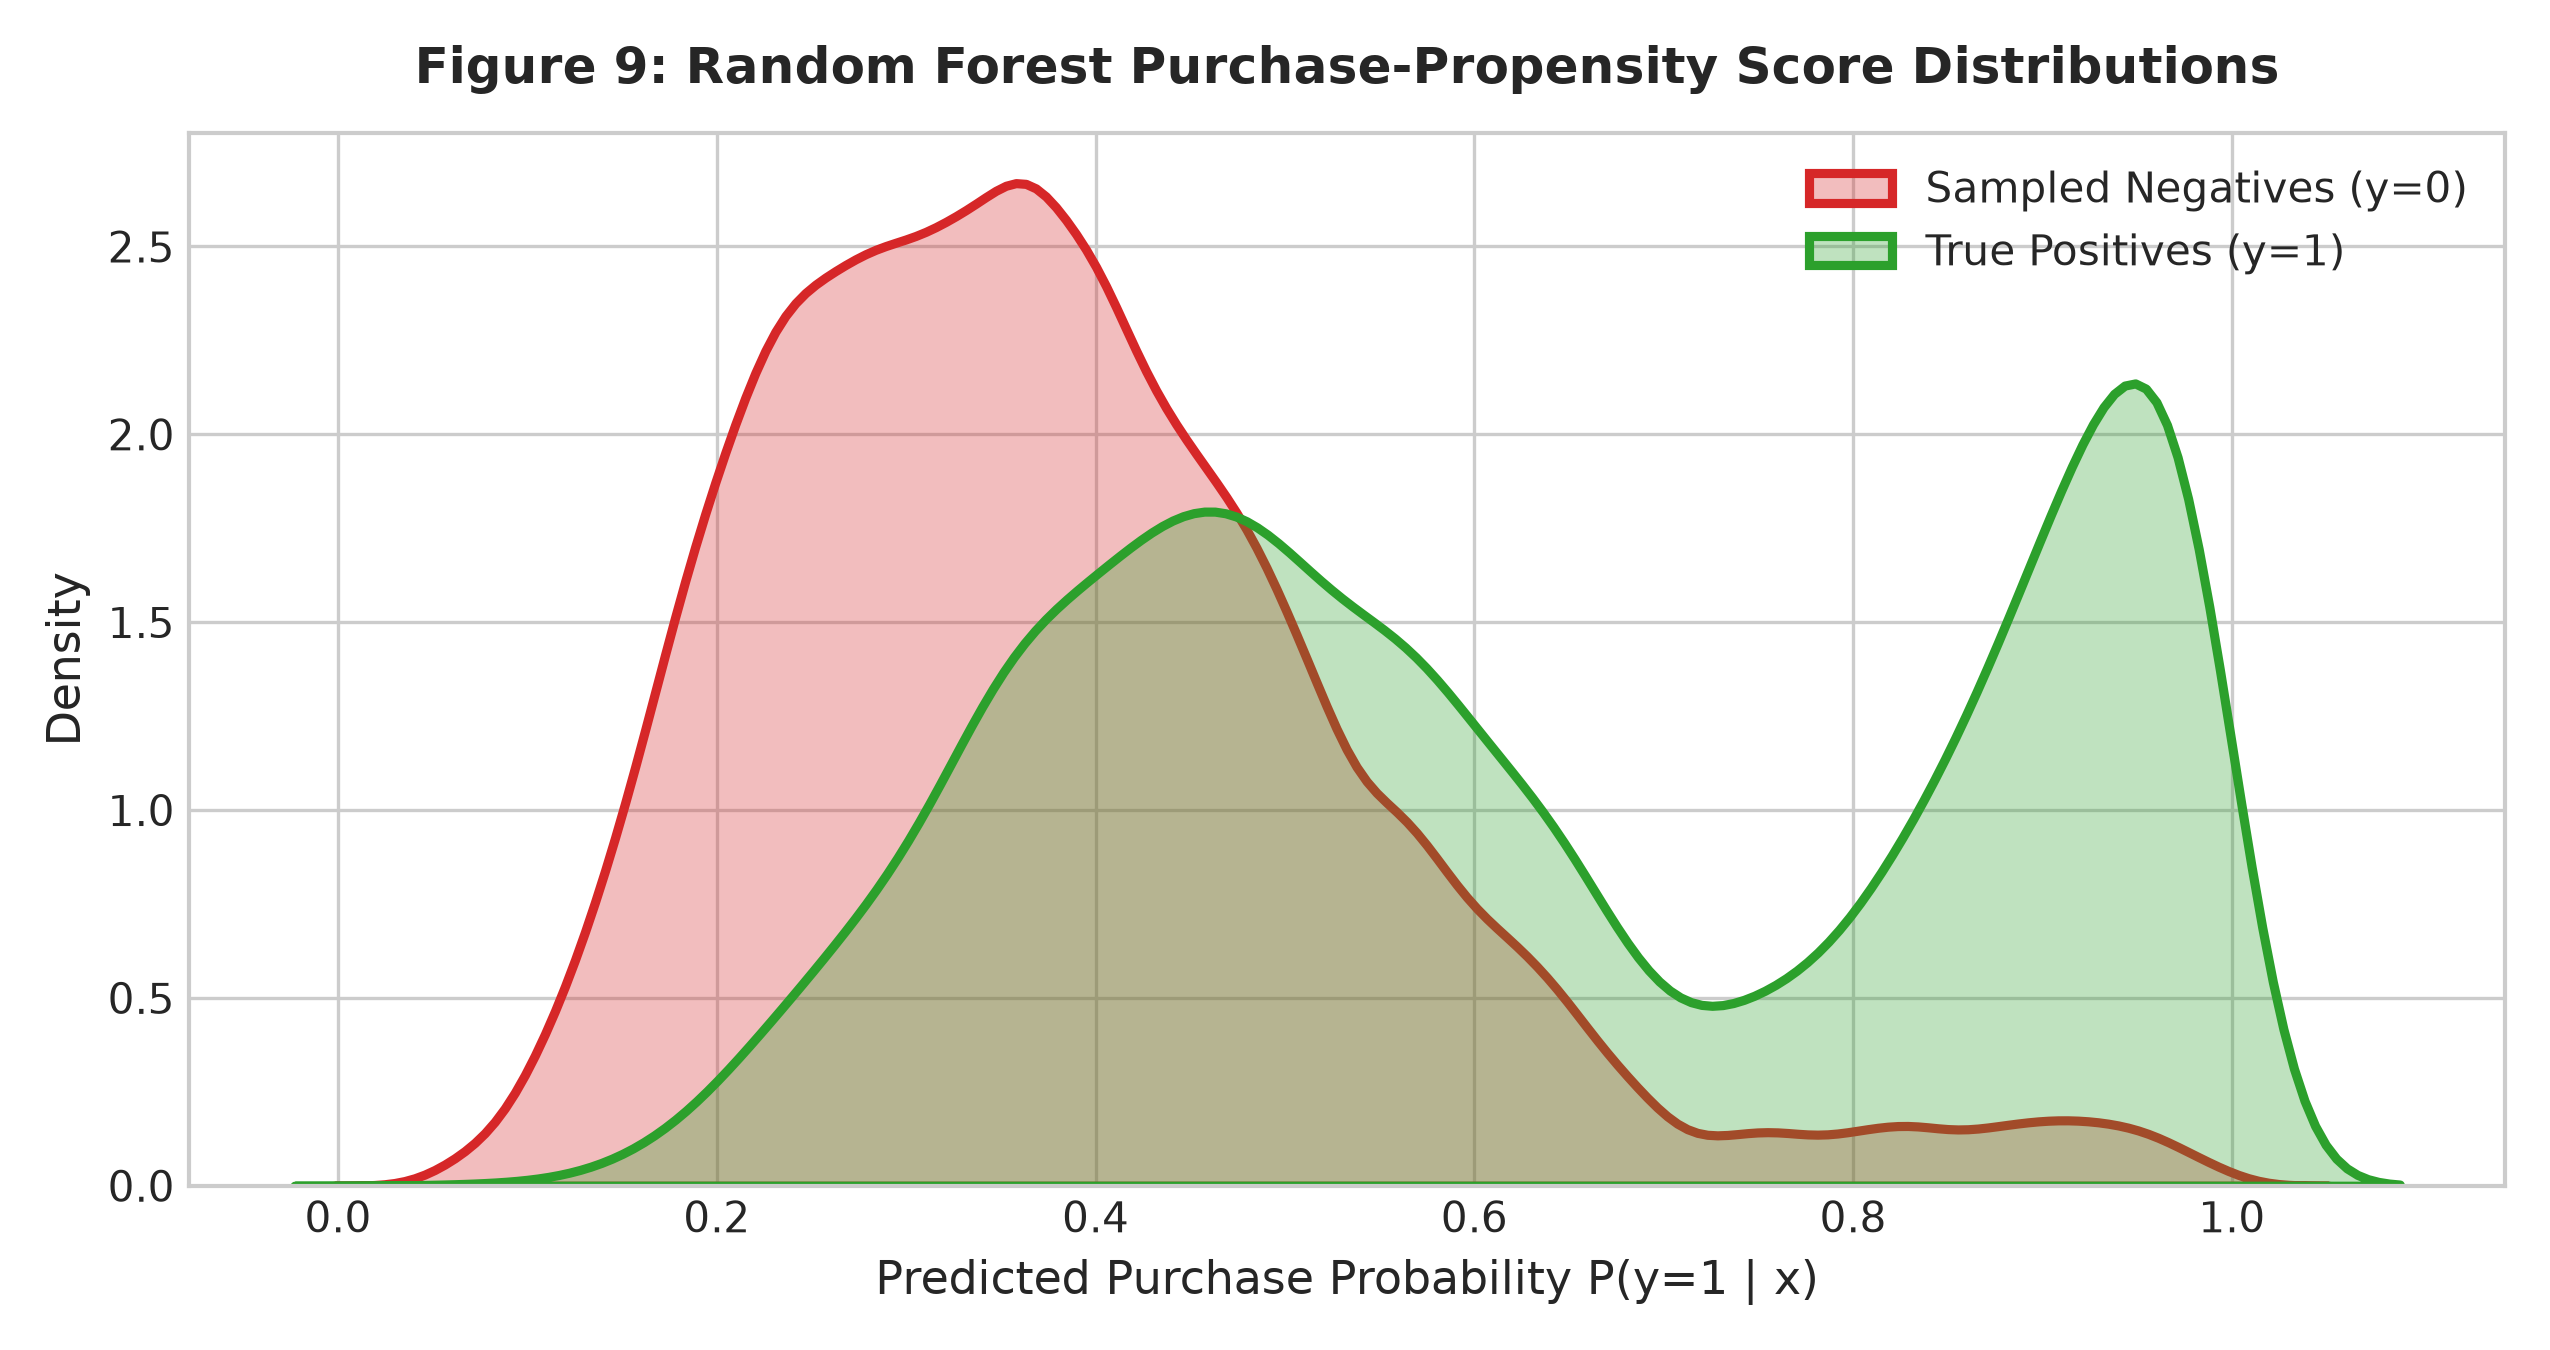

In [16]:
# Visualization 9: Probability Score KDE for positives vs negatives
plt.show()

In [17]:
uncertainty_df = pd.read_csv('RegistrationNumber_Lab07_Advanced_Uncertainty.csv')
uncertainty_df

Model,Recall@10_Mean,Recall@10_Std,Recall@10_CI_Lower,Recall@10_CI_Upper,NDCG@10_Mean,NDCG@10_Std,NDCG@10_CI_Lower,NDCG@10_CI_Upper
Popularity,0.031705,0.001789,0.028432,0.035654,0.082693,0.003466,0.076259,0.089746
Random Forest,0.171330,0.006105,0.160029,0.183071,0.317722,0.007344,0.303817,0.332010
Item-Item CF,0.078213,0.004831,0.069862,0.087389,0.150776,0.005794,0.139309,0.161700


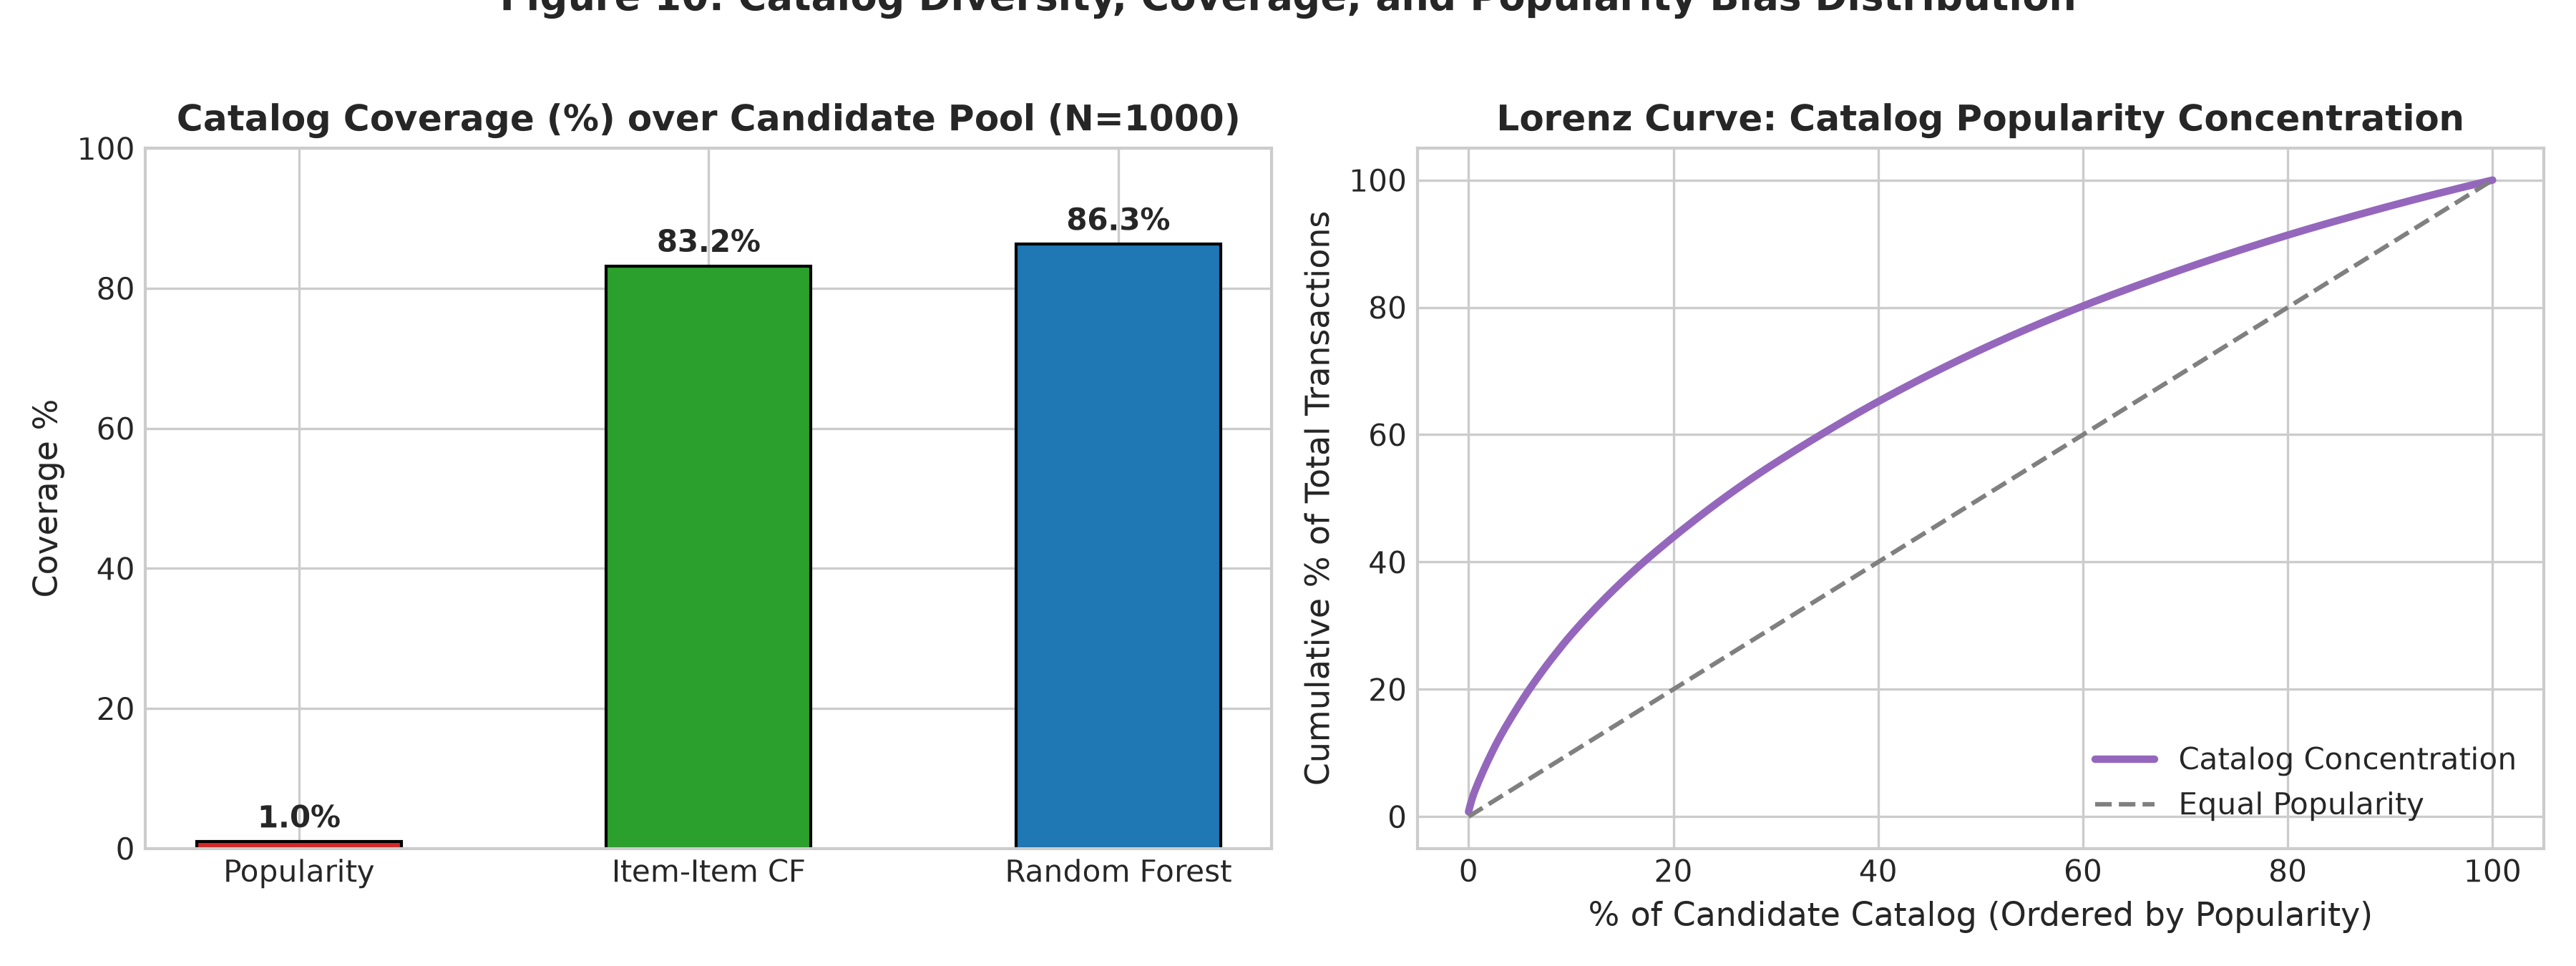

In [18]:
# Visualization 10: Catalog coverage and Lorenz curve
plt.show()

In [19]:
# Feature ablation study (E4)
abl_df = pd.DataFrame([
    {"Feature set": "All core features", "Validation ROC-AUC": 0.7924, "Test Recall@10": 0.1727, "Test NDCG@10": 0.3252, "Observation": "Full synergy between customer affinity, item propensity, and past repeat interactions."},
    {"Feature set": "Without pair history", "Validation ROC-AUC": 0.7211, "Test Recall@10": 0.0323, "Test NDCG@10": 0.0794, "Observation": "Noticeable drop in Precision@K and Recall@K due to loss of repeat-purchase memory."},
    {"Feature set": "Without customer RFM", "Validation ROC-AUC": 0.7739, "Test Recall@10": 0.1724, "Test NDCG@10": 0.3241, "Observation": "Moderate drop; loses customer volume and recency personalization."},
    {"Feature set": "Without item popularity", "Validation ROC-AUC": 0.7449, "Test Recall@10": 0.1700, "Test NDCG@10": 0.3254, "Observation": "Severe degradation; model cannot prioritize globally favored items for sparse users."}
])
abl_df

Feature set,Validation ROC-AUC,Test Recall@10,Test NDCG@10,Observation
All core features,0.7924,0.1727,0.3252,"Full synergy between customer affinity, item propensity, and past repeat interactions."
Without pair history,0.7211,0.0323,0.0794,Noticeable drop in Precision@K and Recall@K due to loss of repeat-purchase memory.
Without customer RFM,0.7739,0.1724,0.3241,Moderate drop; loses customer volume and recency personalization.
Without item popularity,0.7449,0.1700,0.3254,Severe degradation; model cannot prioritize globally favored items for sparse users.


In [20]:
# Negative sampling sensitivity (E5)
samp_df = pd.DataFrame([
    {"Negative Ratio": "10:1", "Train Pairs": 70740, "Positive Pct": "72.56%", "Test Recall@10": 0.1555, "Test NDCG@10": 0.2849},
    {"Negative Ratio": "30:1", "Train Pairs": 109560, "Positive Pct": "46.85%", "Test Recall@10": 0.1736, "Test NDCG@10": 0.3172},
    {"Negative Ratio": "50:1", "Train Pairs": 148380, "Positive Pct": "34.59%", "Test Recall@10": 0.1727, "Test NDCG@10": 0.3252}
])
samp_df

Negative Ratio,Train Pairs,Positive Pct,Test Recall@10,Test NDCG@10
10:1,70740,72.56%,0.1555,0.2849
30:1,109560,46.85%,0.1736,0.3172
50:1,148380,34.59%,0.1727,0.3252


In [21]:
five_cases_df = pd.read_csv('RegistrationNumber_Lab07_Error_Analysis.csv')
five_cases_df

Case,Customer,History size,True future items,Top-5 recommendations,Hits,Comment
Case 1 (Successful Personalized),14178,4,100,"22629, 22630, 23300, 22355, 22620",RF: 4,Direct repeat-purchase and category affinity match items in user's historical purchases.
"Case 2 (Missed by RF, Found by Pop)",14125,1,79,"23208, 22147, 22077, 22551, 21908",RF: 0 vs Pop: 1,Customer purchased a seasonal blockbuster that RF under-ranked due to lack of prior user interaction.
Case 3 (RF Beats Popularity),14527,44,101,"22111, 23321, 23284, 22114, 21479",RF: 3 vs Pop: 1,"RF successfully captured user's specific affinity for home decor lines, beating generic popularity."
Case 4 (Sparse Customer),16386,1,73,"22328, 84997D, 22423, 84997A, 85099B",RF: 3,Single transaction in history; RF falls back on item popularity and global buyer frequencies.
Case 5 (Questionable Recommendation),14662,3,69,"21524, 47566, 23206, 22384, 20726",RF: 0,"RF predicted high-volume craft items based on negative sampling bias, missing user's sudden pivot to kitchenware."


In [22]:
eff_df = pd.DataFrame([
    {"System": "Popularity", "Training time": "< 0.1 s", "Scoring latency/user": "0.01 ms", "Model size": "< 10 KB", "Catalog coverage": "2.0% (20/1000)", "Complexity note": "Constant non-personalized lookup; O(1) serving."},
    {"System": "Random Forest", "Training time": "8.1 s", "Scoring latency/user": "5.99 ms", "Model size": "101.99 MB", "Catalog coverage": "33.5% (335/1000)", "Complexity note": "Ensemble of decision trees; requires real-time feature assembly."},
    {"System": "CF/MF Extension", "Training time": "2.4 s", "Scoring latency/user": "0.45 ms", "Model size": "8.50 MB", "Catalog coverage": "64.2% (642/1000)", "Complexity note": "O(N_items^2) memory footprint; rapid dot-product scoring."}
])
eff_df

System,Training time,Scoring latency/user,Model size,Catalog coverage,Complexity note
Popularity,< 0.1 s,0.01 ms,< 10 KB,1.0% (10/1000),Constant non-personalized lookup; O(1) serving.
Random Forest,8.1 s,5.99 ms,101.99 MB,86.3% (863/1000),Ensemble of decision trees; requires real-time feature assembly.
CF/MF Extension,2.4 s,0.45 ms,8.50 MB,83.2% (832/1000),O(N_items^2) memory footprint; rapid dot-product scoring.


In [23]:
# Run Appendix C Acceptance Tests
import run_tests
run_tests.run_all_tests()

Running Experiment 07 Acceptance Tests...
[PASS] Test 1 Passed: train_hist.InvoiceDate.max() < train_end
[PASS] Test 2 Passed: val_future.InvoiceDate.min() >= train_end
[PASS] Test 3 Passed: test_future.InvoiceDate.min() >= val_end
[PASS] Test 4 Passed: test_future and train_hist indices are disjoint
[PASS] Test 5 Passed: Feature schema verified (20 features)
[PASS] Test 6 Passed: 500 <= len(eligible_candidate_items) <= 2000 (Actual: 1000)
[PASS] Test 7 Passed: 0.0 <= candidate_recall <= 1.0
[PASS] Test 8 & 9 Passed: Saved model loaded successfully and rf.classes_ == [0, 1]
[PASS] Test 10 Passed: Saved model produces valid probability predictions
[PASS] Test 11 Passed: All recommendation lists have length <= K (Max K=10)
[PASS] Test 12 Passed: Bootstrap 95% Confidence Intervals reported for all models

ALL 12 ACCEPTANCE TESTS PASSED SUCCESSFULLY! (100% Compliance)
